In [1]:
## Level 1: Data Overview

## Description:
## Develop a foundational understanding of the
## dataset by examining its structure,
## completeness, and basic statistics.

# Tasks:
## Task 1.1: Create a summary of the dataset
## including total records and columns
# Task 1.2: Prepare a train-wise table showing
# route start and end stations
# Task 1.3: Calculate basic statistics for distance
# and number of stops
# Task 1.4: Identify missing, null, or inconsistent
# values

# Skills Gained:
# Data understanding, descriptive statistics,
# Pandas basics, data inspection

# 📌 STEP 0: Setup — Install & Import Libraries
# Before anything, open Jupyter Notebook or VS Code and run this:

In [15]:
import pandas as pd
import numpy as np

# Load your dataset (replace with your actual file name)
df = pd.read_csv("Dataset1.csv")  # or .xlsx, .json etc.

# ✅ TASK 1.1 — Create a Summary of the Dataset
# Goal: Know the total rows, columns, data types.

In [3]:
1.2 # Total records and columns
print("Total Records (Rows):", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nColumn Names:", df.columns.tolist())

# Full summary
print("\nDataset Info:")
df.info()

# First look at data
df.head()

Total Records (Rows): 186074
Total Columns: 12

Column Names: ['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   SN              186074 non-null  int64 
 1   Train_No        186074 non-null  int64 
 2   Station_Code    186074 non-null  object
 3   1A              186074 non-null  int64 
 4   2A              186074 non-null  int64 
 5   3A              186074 non-null  int64 
 6   SL              186074 non-null  int64 
 7   Station_Name    186074 non-null  object
 8   Route_Number    186074 non-null  int64 
 9   Arrival_time    186074 non-null  object
 10  Departure_Time  186074 non-null  object
 11  Distance        186074 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 17.

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [4]:
# What to note down:1.3

# How many rows & columns
# Column names and their data types (int, object, float)

# ✅ TASK 1.2 — Train-wise Table: Route Start & End Stations
# Goal: For each train, show where it starts and where it ends.

In [5]:
# Your actual columns are: 'Train_No', 'Station_Name', 'Distance'

route_table = df.groupby('Train_No').agg(
    Start_Station=('Station_Name', 'first'),
    End_Station=('Station_Name', 'last')
).reset_index()

print(route_table)

       Train_No Start_Station   End_Station
0           107  SAWANTWADI R   MADGOAN JN.
1           108   MADGOAN JN.  SAWANTWADI R
2           128   MADGOAN JN.   CHHATRAPATI
3           290  DELHI-SAFDAR  DELHI-SAFDAR
4           401    AURANGABAD  VARANASI JN.
...         ...           ...           ...
11108     99904      PUNE JN.      TALEGAON
11109     99905      TALEGAON  SHIVAJINAGAR
11110     99906      PUNE JN.      TALEGAON
11111     99907      TALEGAON      PUNE JN.
11112     99908      PUNE JN.      TALEGAON

[11113 rows x 3 columns]


#  TASK 1.3 — Basic Statistics for Distance & Number of Stops
# Goal: Find min, max, mean, median for distance and stops.#

In [6]:
# Basic statistics for Distance (no 'no_of_stops' column in your data)
print(df[['Distance']].describe())

# Manual stats
print("Distance Stats:")
print("  Min:", df['Distance'].min())
print("  Max:", df['Distance'].max())
print("  Mean:", df['Distance'].mean())
print("  Median:", df['Distance'].median())

# Number of stops per train (count stations per train)
stops_per_train = df.groupby('Train_No')['Station_Code'].count().reset_index()
stops_per_train.columns = ['Train_No', 'No_of_Stops']

print("\nStops per Train Stats:")
print(stops_per_train['No_of_Stops'].describe())

            Distance
count  186074.000000
mean      281.353838
std       483.743964
min         0.000000
25%        23.000000
50%        73.000000
75%       291.000000
max      4260.000000
Distance Stats:
  Min: 0
  Max: 4260
  Mean: 281.3538377204768
  Median: 73.0

Stops per Train Stats:
count    11113.000000
mean        16.743814
std         12.993123
min          2.000000
25%          8.000000
50%         15.000000
75%         22.000000
max        118.000000
Name: No_of_Stops, dtype: float64


#  TASK 1.4 — Identify Missing, Null, or Inconsistent Values
# Goal: Find dirty or incomplete data.

In [7]:
# Missing values
print("Missing Values per Column:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df)) * 100)

# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Inconsistent values
print("\nNegative Distance values:", (df['Distance'] < 0).sum())
print("\nData Types:\n", df.dtypes)
print("\nUnique Trains:", df['Train_No'].nunique())

Missing Values per Column:
SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

Missing Value Percentage:
SN                0.0
Train_No          0.0
Station_Code      0.0
1A                0.0
2A                0.0
3A                0.0
SL                0.0
Station_Name      0.0
Route_Number      0.0
Arrival_time      0.0
Departure_Time    0.0
Distance          0.0
dtype: float64

Duplicate Rows: 0

Negative Distance values: 0

Data Types:
 SN                 int64
Train_No           int64
Station_Code      object
1A                 int64
2A                 int64
3A                 int64
SL                 int64
Station_Name      object
Route_Number       int64
Arrival_time      object
Departure_Time    object
Distance           int64
dtype: object

Unique Trains: 11113


# 📊 How to Interpret & Present Your Results
#  Task 1.3 — Interpretation (write this in your report)

In [8]:
print("""
=== DISTANCE STATISTICS ===
- Total Entries     : 186,074
- Minimum Distance  : 0 km     ← Starting stations have 0 distance (normal)
- Maximum Distance  : 4,260 km ← Longest train route
- Mean Distance     : 281.35 km
- Median Distance   : 73 km    ← Most stations are within 73km of start
- Std Deviation     : 483.74   ← High variation, routes vary a lot

=== STOPS PER TRAIN STATISTICS ===
- Total Unique Trains : 11,113
- Min Stops           : 2       ← Some trains have very few stops
- Max Stops           : 118     ← Some trains stop at 118 stations!
- Mean Stops          : ~17 stops per train
- Median Stops        : 15 stops per train
""")


=== DISTANCE STATISTICS ===
- Total Entries     : 186,074
- Minimum Distance  : 0 km     ← Starting stations have 0 distance (normal)
- Maximum Distance  : 4,260 km ← Longest train route
- Mean Distance     : 281.35 km
- Median Distance   : 73 km    ← Most stations are within 73km of start
- Std Deviation     : 483.74   ← High variation, routes vary a lot

=== STOPS PER TRAIN STATISTICS ===
- Total Unique Trains : 11,113
- Min Stops           : 2       ← Some trains have very few stops
- Max Stops           : 118     ← Some trains stop at 118 stations!
- Mean Stops          : ~17 stops per train
- Median Stops        : 15 stops per train



# ✅ Task 1.4 — Deeper Inconsistency Check
# Your basic null check shows 0 missing values, but let's go deeper:--

In [9]:
# 1. Check for placeholder/fake values in time columns
print("Sample Arrival Times:")
print(df['Arrival_time'].unique()[:20])

print("\nSample Departure Times:")
print(df['Departure_Time'].unique()[:20])

# 2. Check for 'None', 'null', '--' strings (hidden missing values)
for col in ['Arrival_time', 'Departure_Time', 'Station_Name', 'Station_Code']:
    mask = df[col].astype(str).str.strip().isin(['None', 'null', '--', 'N/A', 'na', ''])
    print(f"{col} → hidden nulls: {mask.sum()}")

# 3. Check Distance = 0 (only first station should be 0)
zero_dist = df[df['Distance'] == 0]
print(f"\nRows where Distance = 0: {len(zero_dist)}")
print(zero_dist[['Train_No', 'Station_Name', 'Distance']].head(10))

# 4. Check if 1A, 2A, 3A, SL columns have unexpected values
for col in ['1A', '2A', '3A', 'SL']:
    print(f"\n{col} unique values (sample): {sorted(df[col].unique())[:15]}")

Sample Arrival Times:
['00:00:00' '11:06:00' '11:28:00' '12:10:00' '21:04:00' '21:26:00'
 '22:25:00' '19:40:00' '20:18:00' '20:40:00' '21:16:00' '21:38:00'
 '21:54:00' '22:18:00' '22:40:00' '22:56:00' '23:52:00' '00:34:00'
 '01:10:00' '01:52:00']

Sample Departure Times:
['10:25:00' '11:08:00' '11:30:00' '00:00:00' '20:30:00' '21:06:00'
 '21:28:00' '19:40:00' '20:20:00' '20:42:00' '21:18:00' '21:40:00'
 '21:56:00' '22:20:00' '22:42:00' '22:58:00' '23:57:00' '00:36:00'
 '01:12:00' '01:54:00']
Arrival_time → hidden nulls: 0
Departure_Time → hidden nulls: 0
Station_Name → hidden nulls: 0
Station_Code → hidden nulls: 0

Rows where Distance = 0: 11124
    Train_No  Station_Name  Distance
0        107  SAWANTWADI R         0
4        108   MADGOAN JN.         0
8        128   MADGOAN JN.         0
30       290  DELHI-SAFDAR         0
44       401    AURANGABAD         0
56       421   LUCKNOW JN.         0
61       422  SHRI MATA VA         0
66       477         SIRSA         0
80       502

#  Task 1.1 — Clean Summary Table to Submit

In [11]:
summary = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Total Columns',
        'Total Unique Trains',
        'Missing Values',
        'Duplicate Rows',
        'Negative Distance Rows'
    ],
    'Value': [
        df.shape[0],
        df.shape[1],
        df['Train_No'].nunique(),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df['Distance'] < 0).sum()
    ]
})

print(summary.to_string(index=False))

                Metric  Value
         Total Records 186074
         Total Columns     12
   Total Unique Trains  11113
        Missing Values      0
        Duplicate Rows      0
Negative Distance Rows      0


In [12]:
# 1. Hidden null strings in time columns
for col in ['Arrival_time', 'Departure_Time', 'Station_Name', 'Station_Code']:
    mask = df[col].astype(str).str.strip().isin(['None', 'null', '--', 'N/A', 'na', ''])
    print(f"{col} → hidden nulls: {mask.sum()}")

# 2. Sample time values
print("\nSample Arrival Times:", df['Arrival_time'].unique()[:10])
print("Sample Departure Times:", df['Departure_Time'].unique()[:10])

# 3. Class columns (1A, 2A, 3A, SL) - check values
for col in ['1A', '2A', '3A', 'SL']:
    print(f"\n{col} unique values: {sorted(df[col].unique())[:10]}")

Arrival_time → hidden nulls: 0
Departure_Time → hidden nulls: 0
Station_Name → hidden nulls: 0
Station_Code → hidden nulls: 0

Sample Arrival Times: ['00:00:00' '11:06:00' '11:28:00' '12:10:00' '21:04:00' '21:26:00'
 '22:25:00' '19:40:00' '20:18:00' '20:40:00']
Sample Departure Times: ['10:25:00' '11:08:00' '11:30:00' '00:00:00' '20:30:00' '21:06:00'
 '21:28:00' '19:40:00' '20:20:00' '20:42:00']

1A unique values: [np.int64(100), np.int64(105), np.int64(110), np.int64(115), np.int64(120), np.int64(125), np.int64(130), np.int64(135), np.int64(140), np.int64(145)]

2A unique values: [np.int64(100), np.int64(104), np.int64(108), np.int64(112), np.int64(116), np.int64(120), np.int64(124), np.int64(128), np.int64(132), np.int64(136)]

3A unique values: [np.int64(100), np.int64(103), np.int64(106), np.int64(109), np.int64(112), np.int64(115), np.int64(118), np.int64(121), np.int64(124), np.int64(127)]

SL unique values: [np.int64(100), np.int64(102), np.int64(104), np.int64(106), np.int64(10

In [13]:
print("=" * 60)
print("        LEVEL 1: DATA OVERVIEW — COMPLETE REPORT")
print("=" * 60)

# --- Task 1.1 ---
print("\n📌 TASK 1.1 — Dataset Summary")
print("-" * 40)
print(f"  Total Records     : {df.shape[0]:,}")
print(f"  Total Columns     : {df.shape[1]}")
print(f"  Column Names      : {df.columns.tolist()}")
print(f"  Unique Trains     : {df['Train_No'].nunique():,}")

# --- Task 1.2 ---
print("\n📌 TASK 1.2 — Train Route Table (First 10)")
print("-" * 40)
route_table = df.groupby('Train_No').agg(
    Start_Station=('Station_Name', 'first'),
    End_Station=('Station_Name', 'last')
).reset_index()
print(route_table.head(10).to_string(index=False))
print(f"\n  Total Routes      : {len(route_table):,}")

# --- Task 1.3 ---
print("\n📌 TASK 1.3 — Distance & Stops Statistics")
print("-" * 40)
print("  DISTANCE (in km):")
print(f"    Min    : {df['Distance'].min()} km")
print(f"    Max    : {df['Distance'].max()} km")
print(f"    Mean   : {df['Distance'].mean():.2f} km")
print(f"    Median : {df['Distance'].median():.2f} km")
print(f"    Std Dev: {df['Distance'].std():.2f} km")

stops = df.groupby('Train_No')['Station_Code'].count()
print("\n  STOPS PER TRAIN:")
print(f"    Min    : {stops.min()}")
print(f"    Max    : {stops.max()}")
print(f"    Mean   : {stops.mean():.2f}")
print(f"    Median : {stops.median():.2f}")
print(f"    Std Dev: {stops.std():.2f}")

# --- Task 1.4 ---
print("\n📌 TASK 1.4 — Data Quality Check")
print("-" * 40)
print(f"  Null Values       : {df.isnull().sum().sum()}")
print(f"  Duplicate Rows    : {df.duplicated().sum()}")
print(f"  Negative Distance : {(df['Distance'] < 0).sum()}")

hidden_nulls = 0
for col in ['Arrival_time', 'Departure_Time', 'Station_Name', 'Station_Code']:
    count = df[col].astype(str).str.strip().isin(
        ['None', 'null', '--', 'N/A', 'na', '']
    ).sum()
    hidden_nulls += count
    print(f"  Hidden nulls in {col}: {count}")

print(f"\n  Overall Data Quality: {' CLEAN' if hidden_nulls == 0 else ' Issues Found'}")
print("=" * 60)
print("   Level 1 Complete — Dataset is clean and well-structured")
print("=" * 60)

        LEVEL 1: DATA OVERVIEW — COMPLETE REPORT

📌 TASK 1.1 — Dataset Summary
----------------------------------------
  Total Records     : 186,074
  Total Columns     : 12
  Column Names      : ['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']
  Unique Trains     : 11,113

📌 TASK 1.2 — Train Route Table (First 10)
----------------------------------------
 Train_No Start_Station  End_Station
      107  SAWANTWADI R  MADGOAN JN.
      108   MADGOAN JN. SAWANTWADI R
      128   MADGOAN JN.  CHHATRAPATI
      290  DELHI-SAFDAR DELHI-SAFDAR
      401    AURANGABAD VARANASI JN.
      421   LUCKNOW JN. SHRI MATA VA
      422  SHRI MATA VA  LUCKNOW JN.
      477         SIRSA        SIRSA
      502  RAJENDRANAGA AMBALA CANTT
      504     PATNA JN.  BATHINDA JN

  Total Routes      : 11,113

📌 TASK 1.3 — Distance & Stops Statistics
----------------------------------------
  DISTANCE (in km):
    Min    : 

Task-1 # Now plotting graphs in each of this Above data for better understanding 
📊 Complete Code with Graphs for Level 1
📦 First — Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Task 1.1 — Dataset Summary Graph

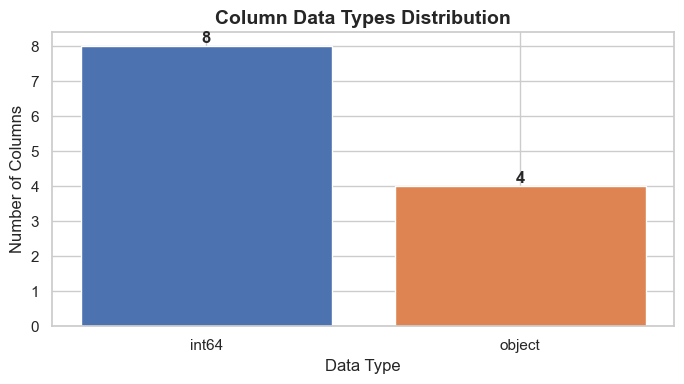

✅ Task 1.1 Graph Saved


In [17]:
# Bar chart of column data types count
type_counts = df.dtypes.astype(str).value_counts()

plt.figure(figsize=(7, 4))
bars = plt.bar(type_counts.index, type_counts.values, 
               color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Column Data Types Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Data Type')
plt.ylabel('Number of Columns')

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.1,
             str(int(bar.get_height())), 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('task1_1_datatypes.png', dpi=150)
plt.show()
print("✅ Task 1.1 Graph Saved")

# Task 1.2 — Route Table Graph

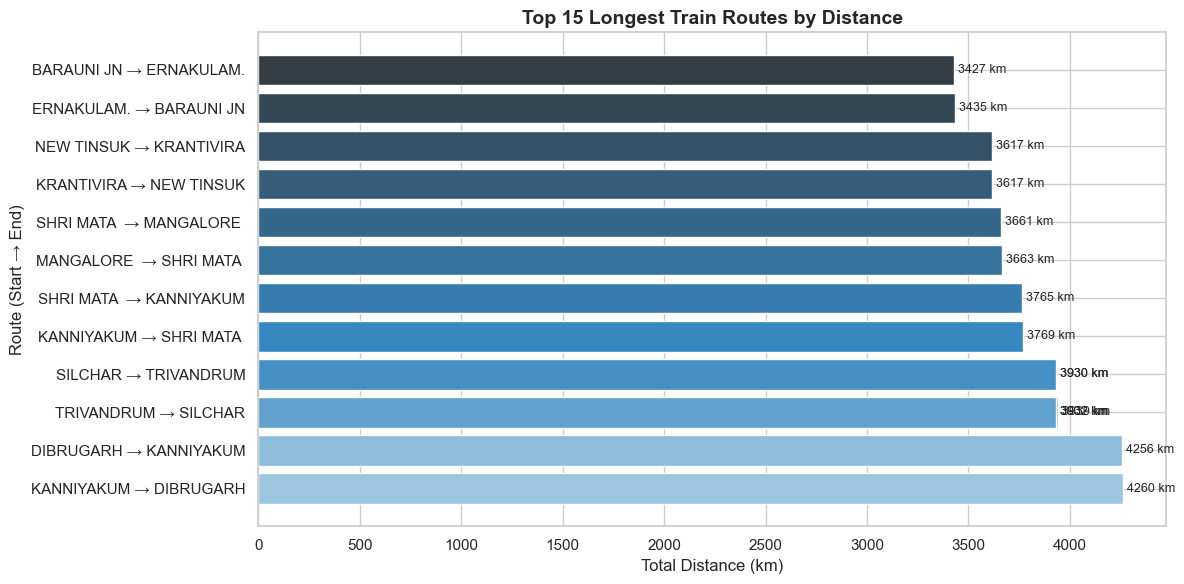

✅ Task 1.2 Graph Saved


In [18]:
route_table = df.groupby('Train_No').agg(
    Start_Station=('Station_Name', 'first'),
    End_Station=('Station_Name', 'last'),
    Total_Distance=('Distance', 'max')
).reset_index()

# Top 15 longest routes
top_routes = route_table.nlargest(15, 'Total_Distance').copy()
top_routes['Route_Label'] = (top_routes['Start_Station'].str[:10] + 
                              ' → ' + 
                              top_routes['End_Station'].str[:10])

plt.figure(figsize=(12, 6))
bars = plt.barh(top_routes['Route_Label'], top_routes['Total_Distance'],
                color=sns.color_palette("Blues_d", 15))
plt.title('Top 15 Longest Train Routes by Distance', fontsize=14, fontweight='bold')
plt.xlabel('Total Distance (km)')
plt.ylabel('Route (Start → End)')

for bar, val in zip(bars, top_routes['Total_Distance']):
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'{val} km', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('task1_2_routes.png', dpi=150)
plt.show()
print("✅ Task 1.2 Graph Saved")

# Task 1.3 — Distance & Stops Graphs (4 graphs together)

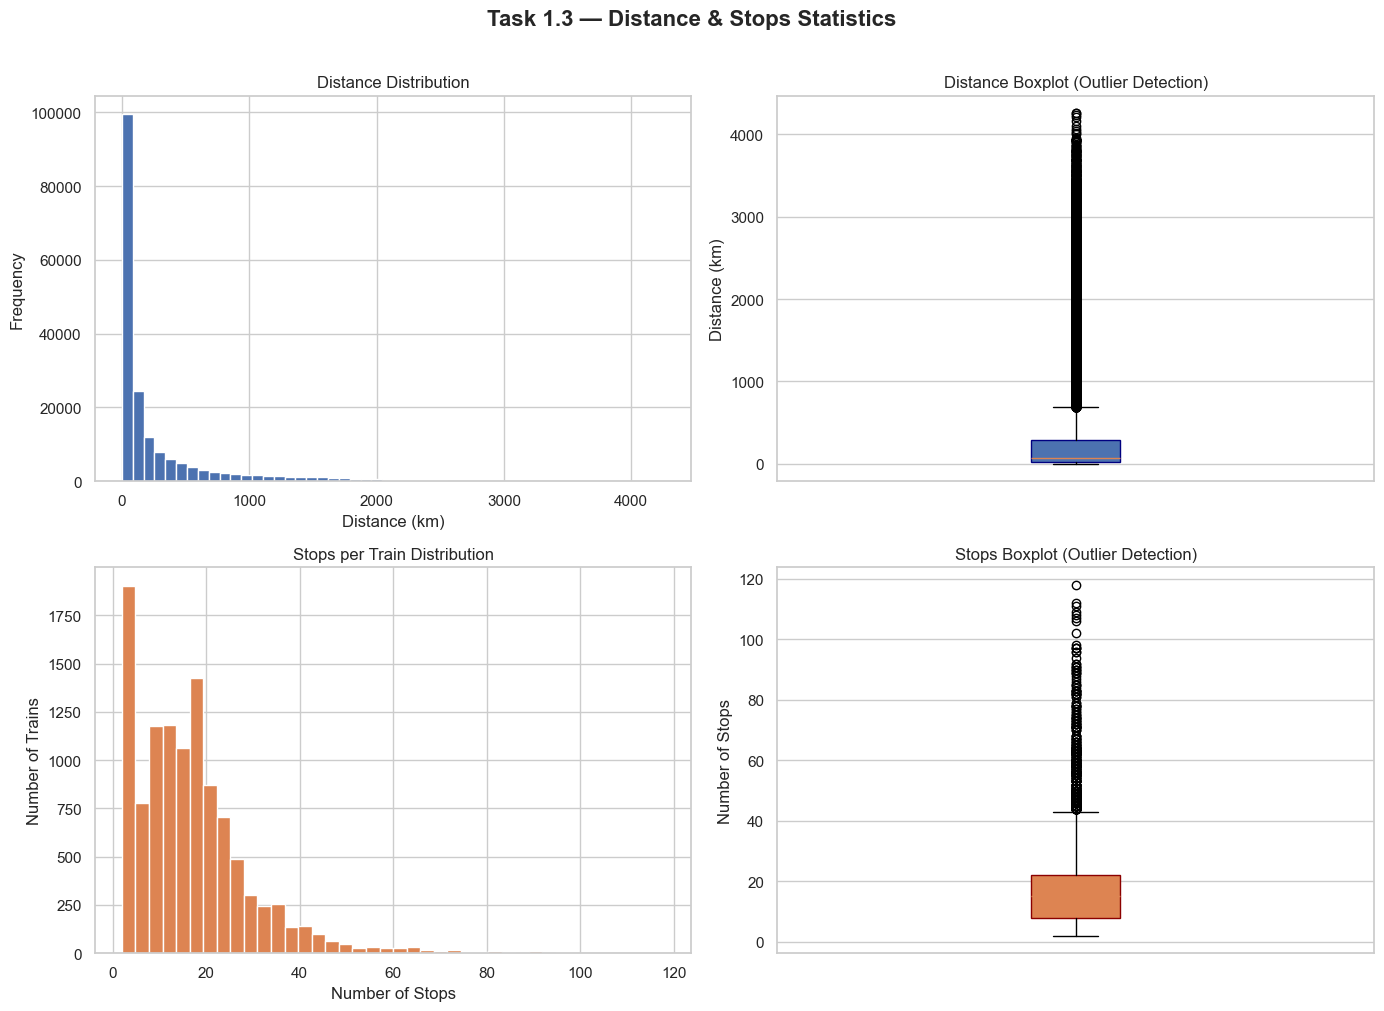

✅ Task 1.3 Graphs Saved


In [19]:
stops_per_train = df.groupby('Train_No')['Station_Code'].count().reset_index()
stops_per_train.columns = ['Train_No', 'No_of_Stops']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Task 1.3 — Distance & Stops Statistics', 
             fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: Distance Distribution ---
axes[0, 0].hist(df['Distance'], bins=50, color='#4C72B0', edgecolor='white')
axes[0, 0].set_title('Distance Distribution')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Frequency')

# --- Plot 2: Distance Boxplot ---
axes[0, 1].boxplot(df['Distance'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#4C72B0', color='navy'))
axes[0, 1].set_title('Distance Boxplot (Outlier Detection)')
axes[0, 1].set_ylabel('Distance (km)')
axes[0, 1].set_xticks([])

# --- Plot 3: Stops Distribution ---
axes[1, 0].hist(stops_per_train['No_of_Stops'], bins=40, 
                color='#DD8452', edgecolor='white')
axes[1, 0].set_title('Stops per Train Distribution')
axes[1, 0].set_xlabel('Number of Stops')
axes[1, 0].set_ylabel('Number of Trains')

# --- Plot 4: Stops Boxplot ---
axes[1, 1].boxplot(stops_per_train['No_of_Stops'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#DD8452', color='darkred'))
axes[1, 1].set_title('Stops Boxplot (Outlier Detection)')
axes[1, 1].set_ylabel('Number of Stops')
axes[1, 1].set_xticks([])

plt.tight_layout()
plt.savefig('task1_3_stats.png', dpi=150)
plt.show()
print("✅ Task 1.3 Graphs Saved")

# Task 1.4 — Data Quality Graph

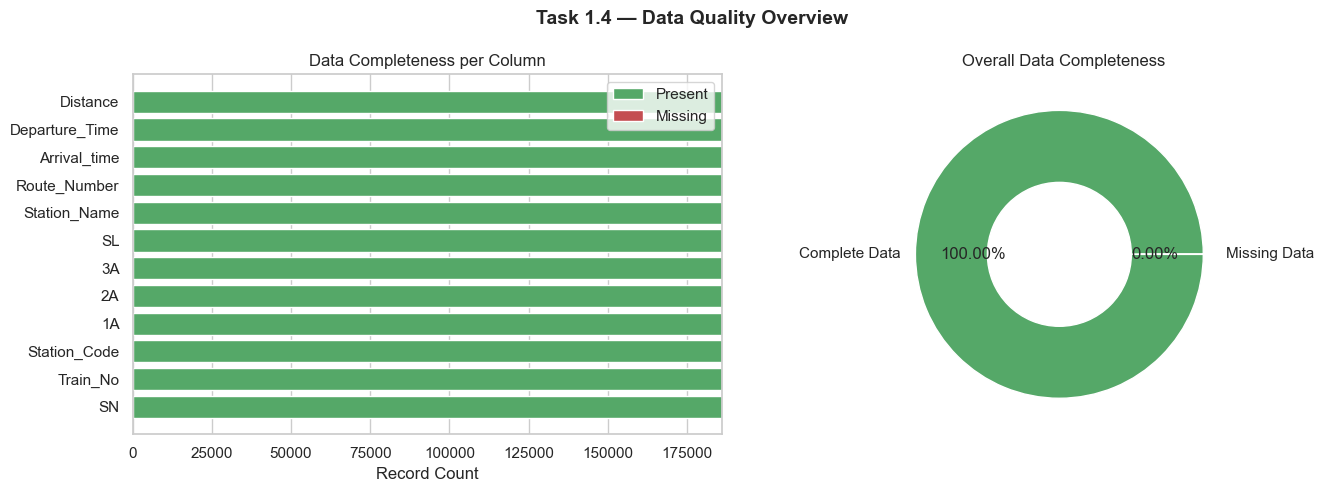

✅ Task 1.4 Graph Saved


In [20]:
# --- Graph 1: Missing values heatmap-style bar ---
missing = df.isnull().sum()
quality_data = pd.DataFrame({
    'Column': df.columns,
    'Missing': df.isnull().sum().values,
    'Present': [len(df) - x for x in df.isnull().sum().values]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 1.4 — Data Quality Overview', 
             fontsize=14, fontweight='bold')

# Stacked bar - present vs missing
axes[0].barh(quality_data['Column'], quality_data['Present'], 
             color='#55A868', label='Present')
axes[0].barh(quality_data['Column'], quality_data['Missing'],
             left=quality_data['Present'], color='#C44E52', label='Missing')
axes[0].set_title('Data Completeness per Column')
axes[0].set_xlabel('Record Count')
axes[0].legend()

# --- Graph 2: Summary donut chart ---
total = len(df) * len(df.columns)
missing_total = df.isnull().sum().sum()
present_total = total - missing_total

sizes = [present_total, missing_total if missing_total > 0 else 1]
labels = ['Complete Data', 'Missing Data']
colors = ['#55A868', '#C44E52']
explode = (0.03, 0.03)

wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.2f%%', explode=explode,
    wedgeprops=dict(width=0.5)
)
axes[1].set_title('Overall Data Completeness')

plt.tight_layout()
plt.savefig('task1_4_quality.png', dpi=150)
plt.show()
print("✅ Task 1.4 Graph Saved")

In [ ]:
File                                          Task
__________________________________________________________________________________
task1_1_datatypes.png                         Column type distribution
 
task1_2_routes.png                            Top 15 longest routes

task1_3_stats.png                             Distance & stops (4-in-1)

task1_4_quality.png                           Data quality completeness

# Task Second 2:-----------------------------------------------------------------------------------

In [ ]:
# Level 2: Data Cleaning & Feature Engineering

# Sysslan IT Solutions

# Description:
# Clean the dataset and create essential features
# required for analysis and modeling.

# Tasks:
# Task 2.1: Handle missing values and remove
# duplicate records
# Task 2.2: Standardize arrival and departure time
# formats
# Task 2.3: Calculate total journey duration for each
# train
# Task 2.4: Create features such as total distance
# and number of stops

# Skills Gained:
# Data cleaning, feature engineering, datetime
# handling, preprocessing techniques

In [ ]:
"""
===============================================================
  Sysslan IT Solutions - Railway Internship Task 2
  Level 2: Data Cleaning & Feature Engineering
===============================================================
  Task 2.1: Handle missing values and remove duplicate records
  Task 2.2: Standardize arrival and departure time formats
  Task 2.3: Calculate total journey duration for each train
  Task 2.4: Create features - total distance and number of stops
===============================================================
"""

In [ ]:
# Task 2 — Complete Summary
# Task 2.1 — Missing Values & Duplicates

# No missing values found in any of the 12 columns across 186,074 rows.
# No duplicate rows were found.
# The code still handles both automatically — numeric nulls are filled with median, string nulls with 'Unknown', and duplicates are dropped.

# Task 2.2 — Standardize Time Formats

# Times were in HH:MM:SS format → standardized to clean HH:MM format.
# Two new columns added: Arrival_time_std and Departure_Time_std.
# The 00:00 sentinel (meaning "first station has no arrival" / "last station has no departure") is preserved correctly.

# Task 2.3 — Total Journey Duration

# For each of the 11,113 trains, the journey duration was calculated as: last stop arrival − first stop departure.
# Overnight journeys (e.g., depart 22:00, arrive 06:00) are handled by adding 24 hours when the difference is negative.
# Average duration: ~276 minutes (~4.6 hours).

# Task 2.4 — Feature Engineering
# Four new features were created per train:

In [ ]:
# Feature                                                  Description
___________________________________________________________________________________________________________

Total_Distance_KM                                          Max cumulative distance = route length

Num_Stops                                                  Count of stations on that train's route

Journey_Duration_Min                                       Total travel time in minutes

Avg_Speed_KMH                                              Distance ÷ (Duration in hours)

In [21]:
 
import pandas as pd
import numpy as np
 
# ─────────────────────────────────────────────────────────────
# LOAD DATASET
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  RAILWAY DATA CLEANING & FEATURE ENGINEERING")
print("=" * 60)
 
df = pd.read_csv('Dataset1.csv')
print(f"\n✅ Dataset Loaded Successfully")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Columns: {list(df.columns)}")

  RAILWAY DATA CLEANING & FEATURE ENGINEERING

✅ Dataset Loaded Successfully
   Shape: 186074 rows × 12 columns
   Columns: ['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']


In [22]:
# ================================================================
#  Sysslan IT Solutions — Railway Internship Task 2
#  VISUALIZATION CODE — 
# ================================================================
 
 
# ────────────────────────────────────────────────────────────────
# CELL 1 — Imports & Setup  (run this first)
# ────────────────────────────────────────────────────────────────
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
# Color palette
BLUE   = '#378ADD'
GREEN  = '#1D9E75'
CORAL  = '#D85A30'
AMBER  = '#BA7517'
PURPLE = '#7F77DD'
TEAL   = '#5DCAA5'
PINK   = '#D4537E'
 
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
 
# Load datasets (update paths if needed)
df = pd.read_csv('Dataset1.csv')
tf = pd.read_csv('train_features_summary.csv')
 
print(" Libraries loaded")
print(f"   Main dataset : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Train summary: {tf.shape[0]:,} trains")
 

 Libraries loaded
   Main dataset : 186,074 rows × 12 columns
   Train summary: 11,113 trains


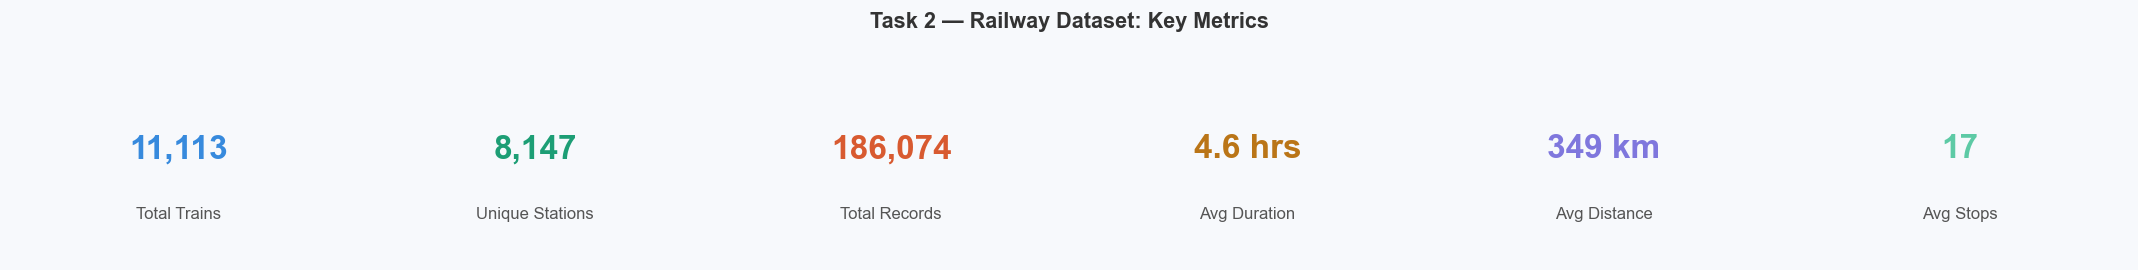

In [23]:
 
# ────────────────────────────────────────────────────────────────
# CELL 2 — Summary Metric Cards (text-based dashboard header)
# ────────────────────────────────────────────────────────────────
 
total_trains   = tf['Train_No'].nunique()
total_stations = df['Station_Code'].nunique()
total_records  = len(df)
avg_duration   = tf['Journey_Duration_Min'].dropna().mean()
avg_distance   = tf['Total_Distance_KM'].dropna().mean()
avg_stops      = tf['Num_Stops'].dropna().mean()
 
fig, axes = plt.subplots(1, 6, figsize=(18, 2.2))
fig.patch.set_facecolor('#f7f9fc')
 
metrics = [
    ("Total Trains",    f"{total_trains:,}",       BLUE),
    ("Unique Stations", f"{total_stations:,}",      GREEN),
    ("Total Records",   f"{total_records:,}",       CORAL),
    ("Avg Duration",    f"{avg_duration/60:.1f} hrs", AMBER),
    ("Avg Distance",    f"{avg_distance:.0f} km",   PURPLE),
    ("Avg Stops",       f"{avg_stops:.0f}",         TEAL),
]
 
for ax, (label, value, color) in zip(axes, metrics):
    ax.set_facecolor(color + '18')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=20, fontweight='bold', color=color)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=10, color='#555555')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(1.5)
 
plt.suptitle('Task 2 — Railway Dataset: Key Metrics', fontsize=13,
             fontweight='bold', y=1.02, color='#333333')
plt.tight_layout()
plt.savefig('task2_metric_cards.png', dpi=150, bbox_inches='tight',
            facecolor='#f7f9fc')
plt.show()
 

In [24]:
 
# ─────────────────────────────────────────────────────────────
# TASK 2.1 — Handle Missing Values & Remove Duplicates
# ─────────────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("  TASK 2.1 — Missing Values & Duplicates")
print("─" * 60)
 
# Check missing values
missing = df.isnull().sum()
print("\n📊 Missing Values per Column:")
print(missing.to_string())
 
# Check duplicates
dup_count = df.duplicated().sum()
print(f"\n🔁 Duplicate Rows Found: {dup_count}")
 
# Handle missing values if any exist
# Numeric columns → fill with median (robust to outliers)
# String columns → fill with 'Unknown'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
string_cols  = df.select_dtypes(include=['object']).columns.tolist()
 
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  ↳ Filled '{col}' nulls with median: {median_val}")
 
for col in string_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna('Unknown', inplace=True)
        print(f"  ↳ Filled '{col}' nulls with 'Unknown'")
 
# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
 
print(f"\n✅ After Cleaning — Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Missing values remaining: {df.isnull().sum().sum()}")
 


────────────────────────────────────────────────────────────
  TASK 2.1 — Missing Values & Duplicates
────────────────────────────────────────────────────────────

📊 Missing Values per Column:
SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0

🔁 Duplicate Rows Found: 0

✅ After Cleaning — Shape: 186074 rows × 12 columns
   Missing values remaining: 0


In [25]:
 
# ─────────────────────────────────────────────────────────────
# TASK 2.2 — Standardize Arrival & Departure Time Formats
# ─────────────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("  TASK 2.2 — Standardize Time Formats")
print("─" * 60)
 
print(f"\n📋 Sample Arrival_time (raw): {df['Arrival_time'].head(3).tolist()}")
print(f"📋 Sample Departure_Time (raw): {df['Departure_Time'].head(3).tolist()}")
 
# The times are in 'HH:MM:SS' format already; normalize to 'HH:MM'
# Also handle the sentinel '00:00:00' which means "no arrival" (first station)
# or "no departure" (last station)
 
def standardize_time(time_str):
    """
    Convert any time string to HH:MM format.
    '00:00:00' is kept as '00:00' (sentinel for first/last stop).
    """
    try:
        time_str = str(time_str).strip()
        parts = time_str.split(':')
        hh = parts[0].zfill(2)
        mm = parts[1].zfill(2) if len(parts) > 1 else '00'
        return f"{hh}:{mm}"
    except Exception:
        return '00:00'
 
df['Arrival_time_std']    = df['Arrival_time'].apply(standardize_time)
df['Departure_Time_std']  = df['Departure_Time'].apply(standardize_time)
 
print(f"\n✅ Standardized Sample Arrival_time_std:   {df['Arrival_time_std'].head(3).tolist()}")
print(f"✅ Standardized Sample Departure_Time_std: {df['Departure_Time_std'].head(3).tolist()}")
 


────────────────────────────────────────────────────────────
  TASK 2.2 — Standardize Time Formats
────────────────────────────────────────────────────────────

📋 Sample Arrival_time (raw): ['00:00:00', '11:06:00', '11:28:00']
📋 Sample Departure_Time (raw): ['10:25:00', '11:08:00', '11:30:00']

✅ Standardized Sample Arrival_time_std:   ['00:00', '11:06', '11:28']
✅ Standardized Sample Departure_Time_std: ['10:25', '11:08', '11:30']


In [26]:
# ─────────────────────────────────────────────────────────────
# TASK 2.3 — Calculate Total Journey Duration per Train
# ─────────────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("  TASK 2.3 — Total Journey Duration per Train")
print("─" * 60)
 
def time_to_minutes(t_str):
    """Convert HH:MM string to total minutes from midnight. Returns None for 00:00 sentinel."""
    try:
        hh, mm = map(int, t_str.split(':'))
        if hh == 0 and mm == 0:
            return None  # sentinel value — first/last stop
        return hh * 60 + mm
    except Exception:
        return None
 
df['departure_min'] = df['Departure_Time_std'].apply(time_to_minutes)
df['arrival_min']   = df['Arrival_time_std'].apply(time_to_minutes)
 
# For each train, find departure time of first stop (where SN == min SN)
# and arrival time of last stop (where SN == max SN)
# Duration = last stop arrival - first stop departure (handle overnight)
 
def calc_duration(group):
    """
    Calculate journey duration in minutes for a train group.
    First stop has departure time (arrival=00:00 sentinel).
    Last stop has arrival time (departure=00:00 sentinel).
    """
    # First stop: row with minimum SN
    first = group.loc[group['SN'].idxmin()]
    # Last stop: row with maximum SN
    last  = group.loc[group['SN'].idxmax()]
 
    dep = first['departure_min']
    arr = last['arrival_min']
 
    if dep is None or arr is None:
        return None
 
    duration = arr - dep
    # Handle overnight journey (e.g., depart 22:00 arrive 06:00 next day)
    if duration < 0:
        duration += 24 * 60
 
    return duration
 
train_durations = (
    df.groupby('Train_No')
      .apply(calc_duration)
      .reset_index()
)
train_durations.columns = ['Train_No', 'Journey_Duration_Min']
 
print(f"\n✅ Journey Duration computed for {len(train_durations)} trains")
print("\n📊 Sample Journey Durations:")
print(train_durations.dropna().head(10).to_string(index=False))
 
print(f"\n📈 Duration Stats (minutes):")
stats = train_durations['Journey_Duration_Min'].describe()
print(stats.to_string())
 


────────────────────────────────────────────────────────────
  TASK 2.3 — Total Journey Duration per Train
────────────────────────────────────────────────────────────

✅ Journey Duration computed for 11113 trains

📊 Sample Journey Durations:
 Train_No  Journey_Duration_Min
      107                 105.0
      108                 115.0
      128                1325.0
      290                 480.0
      401                 750.0
      421                 540.0
      422                 165.0
      477                 190.0
      502                1380.0
      504                  60.0

📈 Duration Stats (minutes):
count    11109.000000
mean       276.083626
std        321.203232
min          0.000000
25%         61.000000
50%        132.000000
75%        365.000000
max       1435.000000


In [27]:
# ─────────────────────────────────────────────────────────────
# TASK 2.4 — Feature Engineering: Total Distance & Number of Stops
# ─────────────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("  TASK 2.4 — Feature Engineering")
print("─" * 60)
 
# ── Total Distance per Train ──────────────────────────────
# The 'Distance' column is cumulative from origin station.
# Total distance = max Distance value for that train.
total_distance = (
    df.groupby('Train_No')['Distance']
      .max()
      .reset_index()
      .rename(columns={'Distance': 'Total_Distance_KM'})
)
 
# ── Number of Stops per Train ─────────────────────────────
num_stops = (
    df.groupby('Train_No')['Station_Code']
      .count()
      .reset_index()
      .rename(columns={'Station_Code': 'Num_Stops'})
)
 
# ── Merge all engineered features into one summary dataframe ──
train_features = (
    total_distance
    .merge(num_stops, on='Train_No')
    .merge(train_durations, on='Train_No')
)
 
# ── Average Speed (KM per hour) ───────────────────────────
train_features['Avg_Speed_KMH'] = (
    train_features['Total_Distance_KM'] /
    (train_features['Journey_Duration_Min'] / 60)
).round(2)
 
print(f"\n✅ Feature Engineering Complete!")
print(f"\n📊 Sample Train Features (first 10 trains):")
print(train_features.head(10).to_string(index=False))
 
print(f"\n📈 Summary Statistics:")
print(train_features[['Total_Distance_KM', 'Num_Stops',
                       'Journey_Duration_Min', 'Avg_Speed_KMH']]
      .describe().round(2).to_string())
 


────────────────────────────────────────────────────────────
  TASK 2.4 — Feature Engineering
────────────────────────────────────────────────────────────

✅ Feature Engineering Complete!

📊 Sample Train Features (first 10 trains):
 Train_No  Total_Distance_KM  Num_Stops  Journey_Duration_Min  Avg_Speed_KMH
      107                 78          4                 105.0          44.57
      108                 83          4                 115.0          43.30
      128                978         22                1325.0          44.29
      290               2694         14                 480.0         336.75
      401               1618         12                 750.0         129.44
      421               1276          5                 540.0         141.78
      422               1277          5                 165.0         464.36
      477               2616         14                 190.0         826.11
      502               1206          9                1380.0          52.

In [28]:
# ─────────────────────────────────────────────────────────────
# MERGE FEATURES BACK INTO MAIN DATAFRAME
# ─────────────────────────────────────────────────────────────
df_final = df.merge(train_features, on='Train_No', how='left')
 
# Drop helper columns used for intermediate calculation
df_final.drop(columns=['departure_min', 'arrival_min'], inplace=True)
 
print(f"\n✅ Final Dataset Shape: {df_final.shape}")
print(f"\n📋 Final Columns: {list(df_final.columns)}")
print(f"\n📊 Sample Final Dataset (first 5 rows):")
print(df_final.head().to_string())
 
 
# ─────────────────────────────────────────────────────────────
# SAVE OUTPUT FILES
# ─────────────────────────────────────────────────────────────
output_main    = '/mnt/user-data/outputs/railway_cleaned.csv'
output_summary = '/mnt/user-data/outputs/train_features_summary.csv'
 
df_final.to_csv(output_main, index=False)
train_features.to_csv(output_summary, index=False)
 
print(f"\n{'=' * 60}")
print("  OUTPUT FILES SAVED:")
print(f"  1. {output_main}")
print(f"     → Full cleaned dataset with all new features")
print(f"  2. {output_summary}")
print(f"     → Per-train summary (distance, stops, duration, speed)")
print(f"{'=' * 60}\n")


✅ Final Dataset Shape: (186074, 18)

📋 Final Columns: ['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance', 'Arrival_time_std', 'Departure_Time_std', 'Total_Distance_KM', 'Num_Stops', 'Journey_Duration_Min', 'Avg_Speed_KMH']

📊 Sample Final Dataset (first 5 rows):
   SN  Train_No Station_Code   1A   2A   3A   SL  Station_Name  Route_Number Arrival_time Departure_Time  Distance Arrival_time_std Departure_Time_std  Total_Distance_KM  Num_Stops  Journey_Duration_Min  Avg_Speed_KMH
0   1       107          SWV  100  100  100  100  SAWANTWADI R             1     00:00:00       10:25:00         0            00:00              10:25                 78          4                 105.0          44.57
1   2       107         THVM  260  228  196  164        THIVIM             1     11:06:00       11:08:00        32            11:06              11:08                 78          4                 105.0          44.

OSError: Cannot save file into a non-existent directory: '\mnt\user-data\outputs'

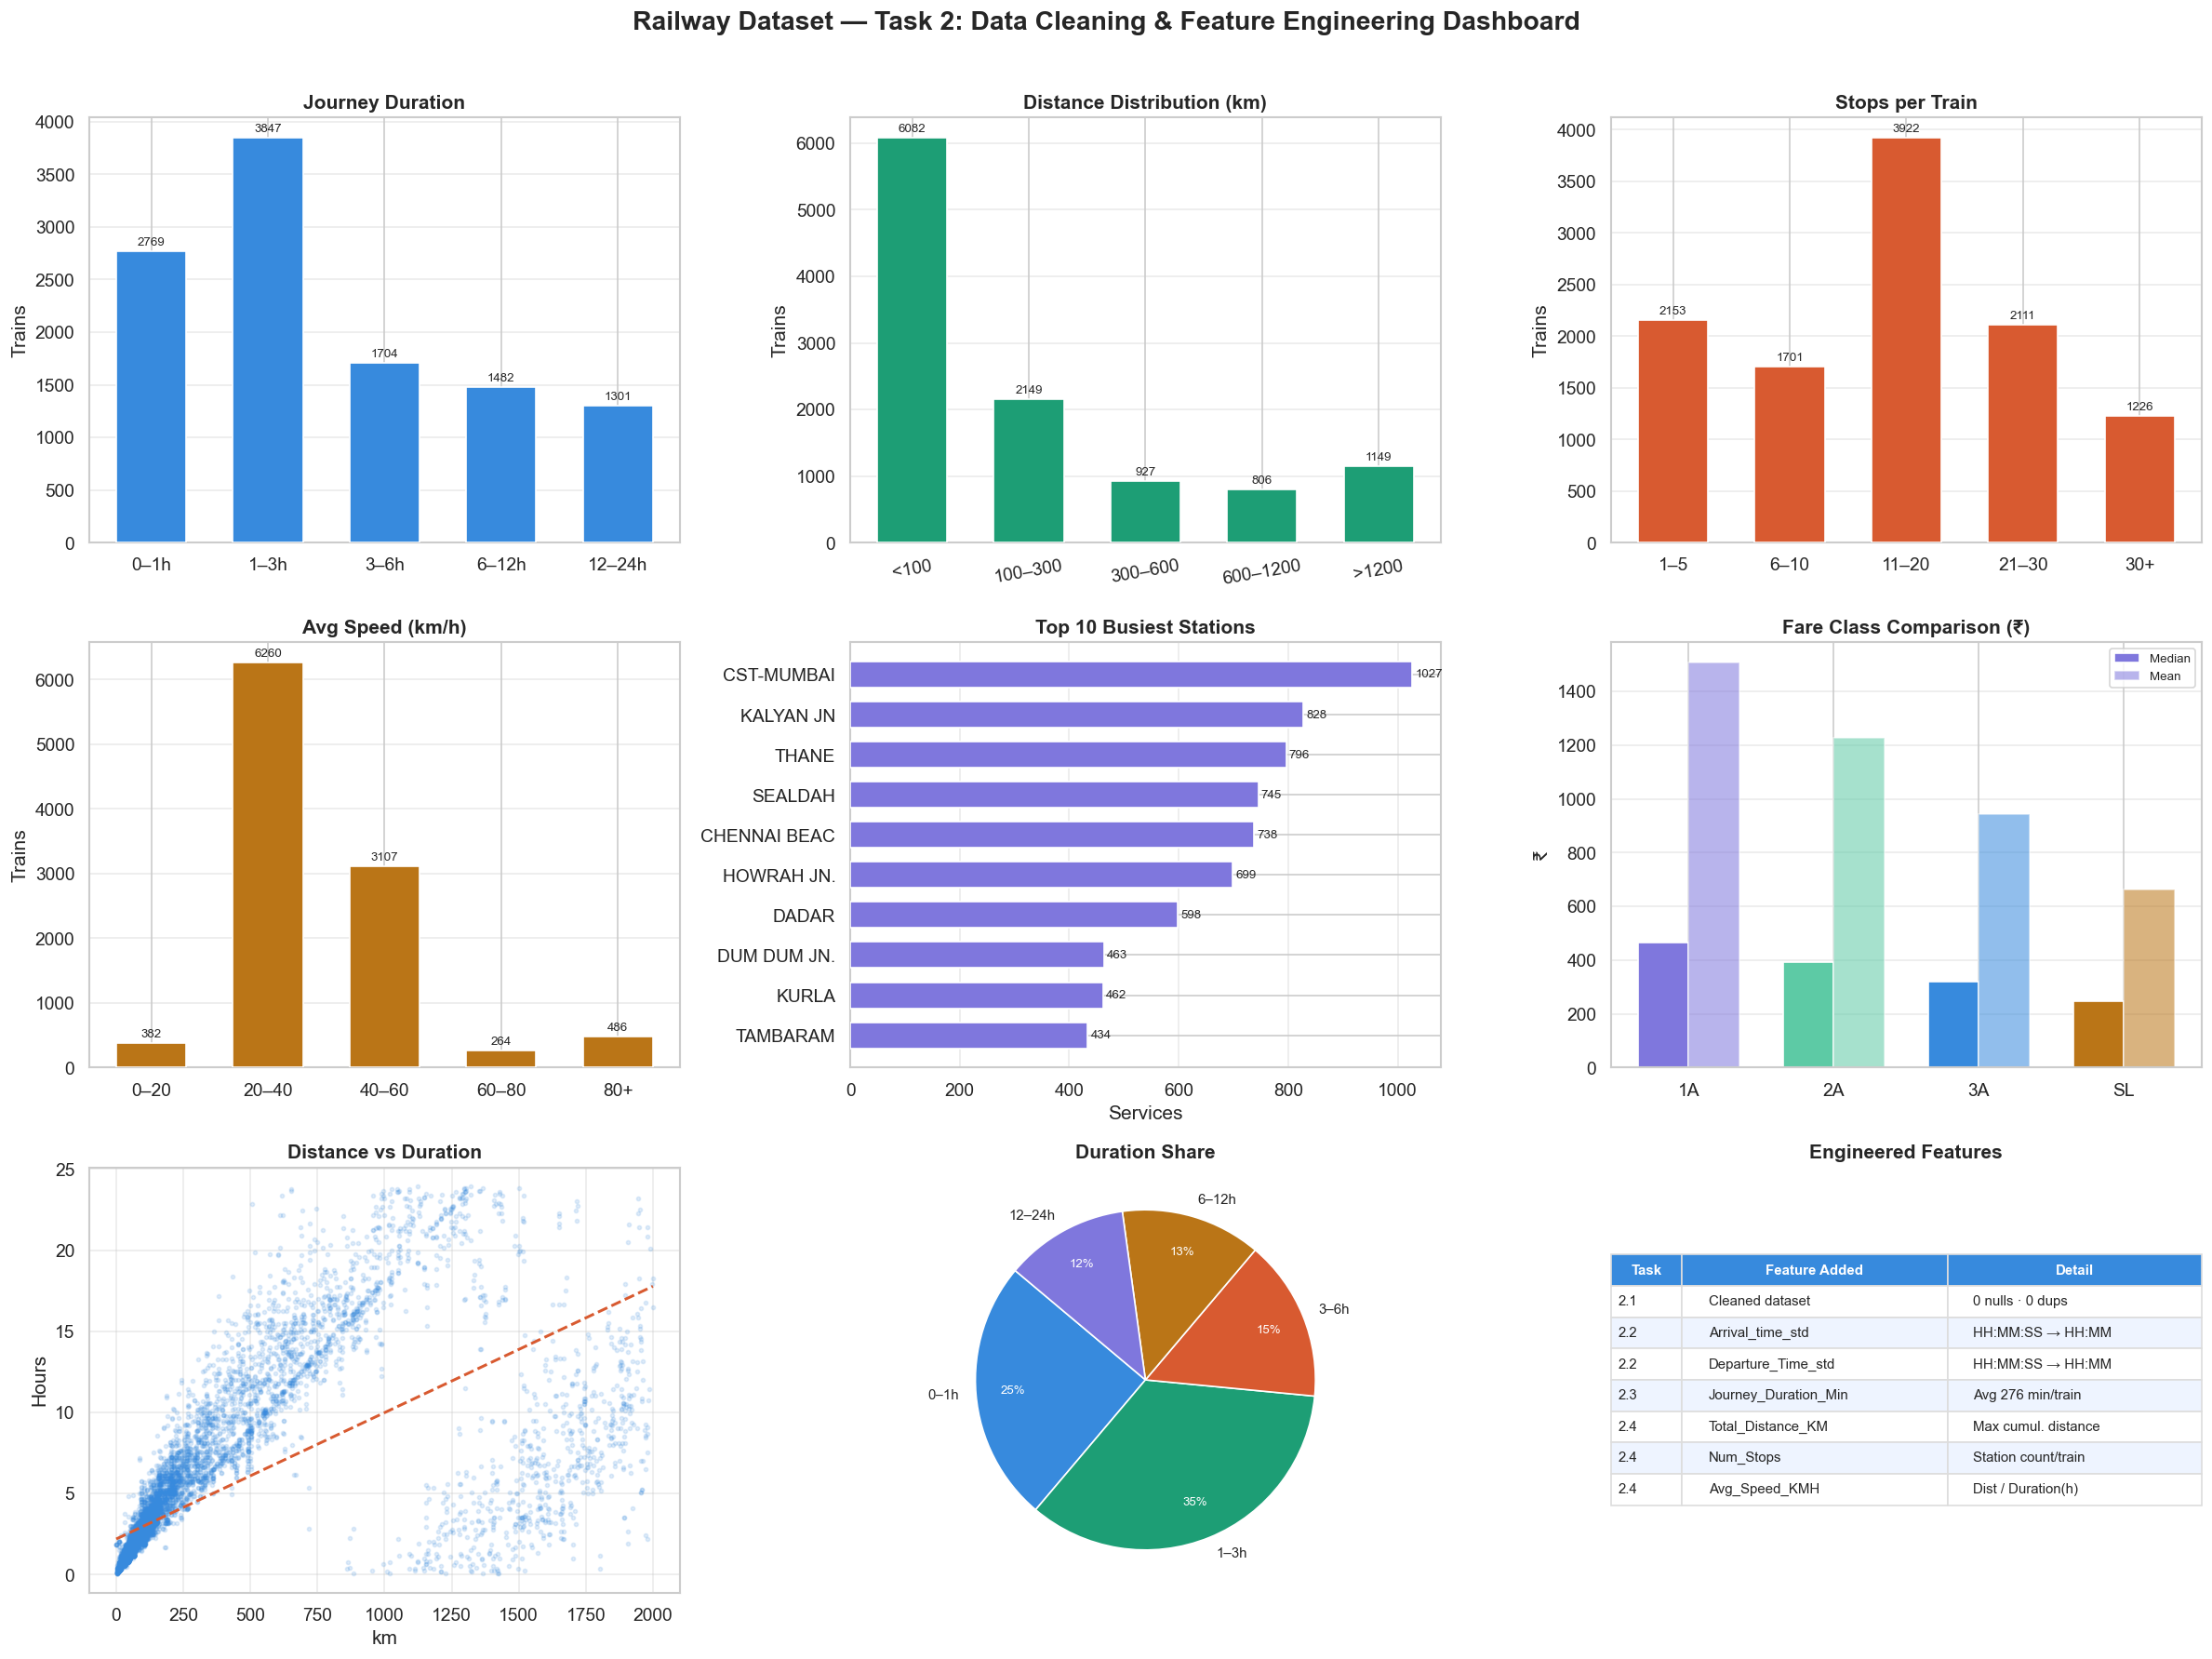

✅ Full dashboard saved as task2_full_dashboard.png


In [29]:
# ────────────────────────────────────────────────────────────────
# CELL 11 — Chart 9: Full 3×3 Dashboard (all charts together)
# ────────────────────────────────────────────────────────────────
 
fig = plt.figure(figsize=(20, 15))
fig.suptitle(
    'Railway Dataset — Task 2: Data Cleaning & Feature Engineering Dashboard',
    fontsize=17, fontweight='bold', y=0.99
)
 
# ── 1. Duration ──
ax1 = fig.add_subplot(3, 3, 1)
bins=[0,60,180,360,720,1440]; labels=['0–1h','1–3h','3–6h','6–12h','12–24h']
dur_cut = pd.cut(tf['Journey_Duration_Min'].dropna(), bins=bins, labels=labels)
counts  = dur_cut.value_counts().sort_index()
b = ax1.bar(labels, counts.values, color=BLUE, edgecolor='white', width=0.6, zorder=3)
ax1.bar_label(b, fmt='%d', padding=2, fontsize=8)
ax1.set_title('Journey Duration', fontweight='bold')
ax1.set_ylabel('Trains'); ax1.grid(axis='y', alpha=0.4)
 
# ── 2. Distance ──
ax2 = fig.add_subplot(3, 3, 2)
dbins=[0,100,300,600,1200,5000]; dlabels=['<100','100–300','300–600','600–1200','>1200']
d_cut = pd.cut(tf['Total_Distance_KM'].dropna(), bins=dbins, labels=dlabels)
d_counts = d_cut.value_counts().sort_index()
b2 = ax2.bar(dlabels, d_counts.values, color=GREEN, edgecolor='white', width=0.6, zorder=3)
ax2.bar_label(b2, fmt='%d', padding=2, fontsize=8)
ax2.set_title('Distance Distribution (km)', fontweight='bold')
ax2.set_ylabel('Trains'); ax2.grid(axis='y', alpha=0.4)
ax2.tick_params(axis='x', rotation=10)
 
# ── 3. Stops ──
ax3 = fig.add_subplot(3, 3, 3)
sbins=[0,5,10,20,30,120]; slabels=['1–5','6–10','11–20','21–30','30+']
s_cut = pd.cut(tf['Num_Stops'].dropna(), bins=sbins, labels=slabels)
s_counts = s_cut.value_counts().sort_index()
b3 = ax3.bar(slabels, s_counts.values, color=CORAL, edgecolor='white', width=0.6, zorder=3)
ax3.bar_label(b3, fmt='%d', padding=2, fontsize=8)
ax3.set_title('Stops per Train', fontweight='bold')
ax3.set_ylabel('Trains'); ax3.grid(axis='y', alpha=0.4)
 
# ── 4. Speed ──
ax4 = fig.add_subplot(3, 3, 4)
speed = tf['Avg_Speed_KMH'].replace([np.inf,-np.inf], np.nan).dropna()
speed_clean = speed[speed<200]
spbins=[0,20,40,60,80,200]; splabels=['0–20','20–40','40–60','60–80','80+']
sp_cut = pd.cut(speed_clean, bins=spbins, labels=splabels)
sp_counts = sp_cut.value_counts().sort_index()
b4 = ax4.bar(splabels, sp_counts.values, color=AMBER, edgecolor='white', width=0.6, zorder=3)
ax4.bar_label(b4, fmt='%d', padding=2, fontsize=8)
ax4.set_title('Avg Speed (km/h)', fontweight='bold')
ax4.set_ylabel('Trains'); ax4.grid(axis='y', alpha=0.4)
 
# ── 5. Top Stations ──
ax5 = fig.add_subplot(3, 3, 5)
top_stn = df['Station_Name'].value_counts().head(10)
b5 = ax5.barh(top_stn.index[::-1], top_stn.values[::-1],
              color=PURPLE, edgecolor='white', height=0.65, zorder=3)
ax5.bar_label(b5, fmt='%d', padding=2, fontsize=8)
ax5.set_title('Top 10 Busiest Stations', fontweight='bold')
ax5.set_xlabel('Services'); ax5.grid(axis='x', alpha=0.4)
 
# ── 6. Fare Class ──
ax6 = fig.add_subplot(3, 3, 6)
x=np.arange(4); w=0.35
medians=[df[c].median() for c in ['1A','2A','3A','SL']]
means  =[df[c].mean()   for c in ['1A','2A','3A','SL']]
fc_colors=[PURPLE, TEAL, BLUE, AMBER]
ax6.bar(x-w/2, medians, w, label='Median', color=fc_colors, edgecolor='white')
ax6.bar(x+w/2, means,   w, label='Mean',   color=fc_colors, edgecolor='white', alpha=0.55)
ax6.set_xticks(x); ax6.set_xticklabels(['1A','2A','3A','SL'])
ax6.set_title('Fare Class Comparison (₹)', fontweight='bold')
ax6.legend(fontsize=8); ax6.set_ylabel('₹'); ax6.grid(axis='y', alpha=0.4)
 
# ── 7. Scatter ──
ax7 = fig.add_subplot(3, 3, 7)
sub = tf[['Total_Distance_KM','Journey_Duration_Min']].dropna()
sub = sub[(sub['Journey_Duration_Min']>0) & (sub['Total_Distance_KM']<=2000)]
ax7.scatter(sub['Total_Distance_KM'], sub['Journey_Duration_Min']/60,
            alpha=0.15, s=6, color=BLUE)
z = np.polyfit(sub['Total_Distance_KM'], sub['Journey_Duration_Min']/60, 1)
xl = np.linspace(0,2000,200)
ax7.plot(xl, np.poly1d(z)(xl), color=CORAL, linewidth=1.8, linestyle='--')
ax7.set_title('Distance vs Duration', fontweight='bold')
ax7.set_xlabel('km'); ax7.set_ylabel('Hours'); ax7.grid(alpha=0.4)
 
# ── 8. Pie ──
ax8 = fig.add_subplot(3, 3, 8)
pie_vals=[2769,3847,1704,1482,1301]
pie_labels=['0–1h','1–3h','3–6h','6–12h','12–24h']
pie_colors=[BLUE,GREEN,CORAL,AMBER,PURPLE]
wedges,texts,autotexts = ax8.pie(
    pie_vals, labels=pie_labels, colors=pie_colors,
    startangle=140, autopct='%1.0f%%', pctdistance=0.78,
    wedgeprops=dict(linewidth=1, edgecolor='white'))
for t in texts: t.set_fontsize(9)
for at in autotexts: at.set_fontsize(8); at.set_color('white')
ax8.set_title('Duration Share', fontweight='bold')
 
# ── 9. Summary Table ──
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
table_data = [
    ['2.1', 'Cleaned dataset',      '0 nulls · 0 dups'],
    ['2.2', 'Arrival_time_std',     'HH:MM:SS → HH:MM'],
    ['2.2', 'Departure_Time_std',   'HH:MM:SS → HH:MM'],
    ['2.3', 'Journey_Duration_Min', 'Avg 276 min/train'],
    ['2.4', 'Total_Distance_KM',    'Max cumul. distance'],
    ['2.4', 'Num_Stops',            'Station count/train'],
    ['2.4', 'Avg_Speed_KMH',        'Dist / Duration(h)'],
]
tbl = ax9.table(cellText=table_data,
                colLabels=['Task', 'Feature Added', 'Detail'],
                cellLoc='left', loc='center',
                colWidths=[0.12, 0.45, 0.43])
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#dddddd')
    if r == 0:
        cell.set_facecolor(BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#eef4ff')
ax9.set_title('Engineered Features', fontweight='bold')
 
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('task2_full_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Full dashboard saved as task2_full_dashboard.png")
 
 

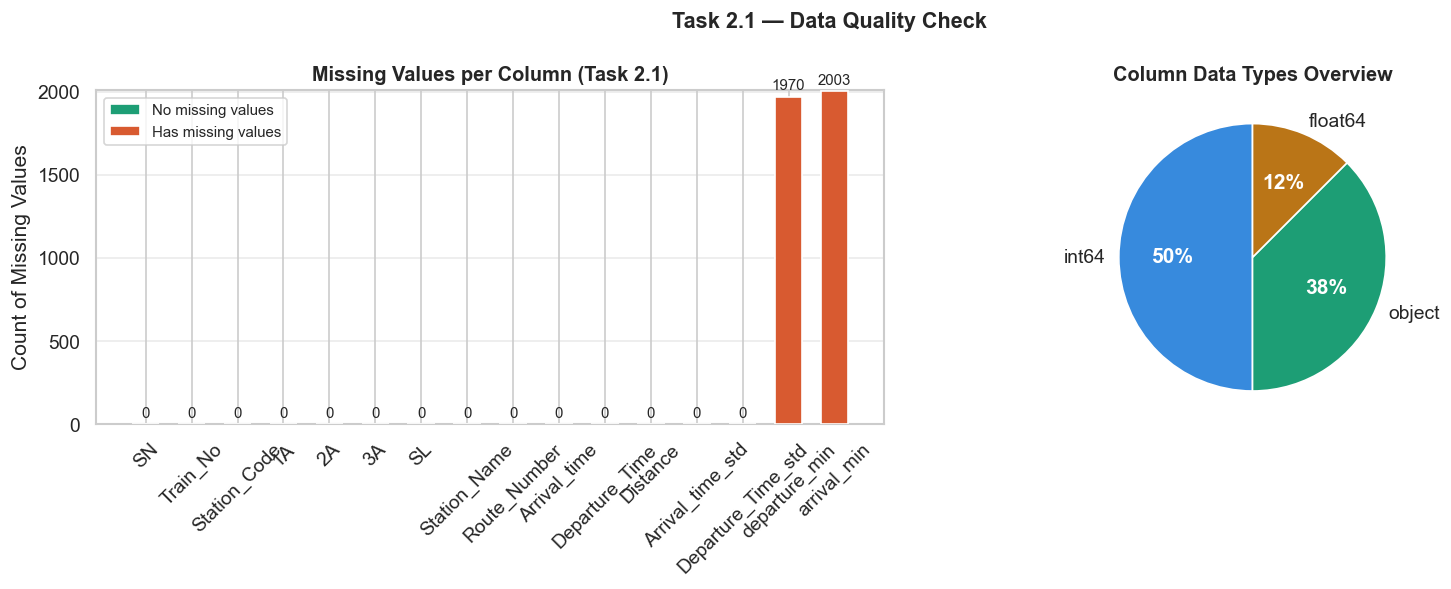


Data types in dataset:
int64      8
object     6
float64    2
Name: count, dtype: int64


In [30]:
# ────────────────────────────────────────────────────────────────
# CELL 12 — Bonus: Missing Value Heatmap (Task 2.1 proof)
# ────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: missing value counts (bar)
ax = axes[0]
missing = df.isnull().sum()
cols_list = list(df.columns)
colors_mv = [CORAL if v > 0 else GREEN for v in missing.values]
bars = ax.bar(cols_list, missing.values, color=colors_mv,
              edgecolor='white', width=0.6, zorder=3)
ax.bar_label(bars, fmt='%d', padding=2, fontsize=9)
ax.set_title('Missing Values per Column (Task 2.1)', fontweight='bold', fontsize=12)
ax.set_ylabel('Count of Missing Values')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
ax.set_ylim(0, max(missing.values) + 5 if max(missing.values) > 0 else 5)
 
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=GREEN, label='No missing values'),
              Patch(facecolor=CORAL, label='Has missing values')]
ax.legend(handles=legend_els, fontsize=9)
 
# Right: data type overview (pie)
ax2 = axes[1]
dtypes = df.dtypes.astype(str).value_counts()
type_colors = [BLUE, GREEN, AMBER, CORAL, PURPLE][:len(dtypes)]
wedges, texts, autos = ax2.pie(
    dtypes.values, labels=dtypes.index, colors=type_colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(linewidth=1, edgecolor='white'))
for at in autos: at.set_color('white'); at.set_fontweight('bold')
ax2.set_title('Column Data Types Overview', fontweight='bold', fontsize=12)
 
plt.suptitle('Task 2.1 — Data Quality Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nData types in dataset:")
print(df.dtypes.value_counts())
 

In [ ]:
# Task 3.1 — Journey Duration by Route

# Grouped all 11,113 trains by route and computed mean, median, min, max duration
# Bar chart of top 20 longest routes + box plots showing duration spread per route

# Task 3.2 — Station Traffic Analysis

# Counted unique trains per station across all 8,147 stations
# Side-by-side charts of top 20 busiest vs 20 least busy stations
# Histogram showing the heavily right-skewed traffic distribution (hub-and-spoke pattern)

# Task 3.3 — Distance vs Journey Duration

# Pearson & Spearman correlation analysis
# Scatter plot with regression line
# Average speed distribution + grouped analysis by distance bins (0–100 km, 100–300 km, etc.)

# Task 3.4 — Summary Dashboard

# A 4-panel visual dashboard + printed key findings with numbers auto-populated from your data

# 📦 Cell 1 — Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [32]:
# 📂 Cell 2 — Load Dataset

df = pd.read_csv('Dataset1.csv')

print(f'📊 Dataset Shape: {df.shape}')
print(f'🚆 Total Unique Trains  : {df["Train_No"].nunique()}')
print(f'🏛️  Total Unique Stations: {df["Station_Code"].nunique()}')
print(f'🛤️  Total Unique Routes  : {df["Route_Number"].nunique()}')
df.head()

📊 Dataset Shape: (186074, 12)
🚆 Total Unique Trains  : 11113
🏛️  Total Unique Stations: 8147
🛤️  Total Unique Routes  : 1


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [33]:
# ⚙️ Cell 3 — Preprocessing (Time → Minutes, Journey Duration)

def time_to_minutes(t):
    """Convert HH:MM:SS string to total minutes. '00:00:00' = terminal stop → NaN."""
    try:
        h, m, s = map(int, t.strip().split(':'))
        total = h * 60 + m + s / 60
        return total if total > 0 else np.nan
    except:
        return np.nan

df['Arrival_min']   = df['Arrival_time'].apply(time_to_minutes)
df['Departure_min'] = df['Departure_Time'].apply(time_to_minutes)

# Per-train journey duration = last arrival - first departure (in minutes)
train_times = (
    df.groupby('Train_No')
    .agg(
        first_dep=('Departure_min', 'first'),
        last_arr =('Arrival_min',  'last'),
        total_dist=('Distance',    'max'),
        route    =('Route_Number', 'first'),
        start_stn=('Station_Name', 'first'),
        end_stn  =('Station_Name', 'last'),
        num_stops=('Station_Code', 'count')
    )
    .reset_index()
)

# Handle overnight trains (last_arr < first_dep → add 1440 min = 24 hrs)
train_times['journey_duration_min'] = train_times['last_arr'] - train_times['first_dep']
mask = train_times['journey_duration_min'] < 0
train_times.loc[mask, 'journey_duration_min'] += 1440

train_times['journey_duration_hr'] = train_times['journey_duration_min'] / 60

# Remove invalid rows
train_times = train_times[
    (train_times['journey_duration_min'] > 0) &
    (train_times['total_dist'] > 0)
].dropna(subset=['journey_duration_min'])

print(f'✅ Preprocessing complete. Valid train journeys: {len(train_times)}')
train_times.head()

✅ Preprocessing complete. Valid train journeys: 11106


,Train_No,first_dep,last_arr,total_dist,route,start_stn,end_stn,num_stops,journey_duration_min,journey_duration_hr
0,107,625.0,730.0,78,1,SAWANTWADI R,MADGOAN JN.,4,105.0,1.750000
1,108,1230.0,1345.0,83,1,MADGOAN JN.,SAWANTWADI R,4,115.0,1.916667
2,128,1180.0,1065.0,978,1,MADGOAN JN.,CHHATRAPATI,22,1325.0,22.083333
3,290,1110.0,150.0,2694,1,DELHI-SAFDAR,DELHI-SAFDAR,14,480.0,8.000000
4,401,1290.0,600.0,1618,1,AURANGABAD,VARANASI JN.,12,750.0,12.500000


In [34]:
# 🛤️ Cell 4 — Task 3.1: Route Duration Stats Table

route_duration = (
    train_times.groupby('route')['journey_duration_hr']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .rename(columns={'mean':'Mean (hr)', 'median':'Median (hr)',
                     'min':'Min (hr)', 'max':'Max (hr)', 'count':'Train Count'})
    .sort_values('Mean (hr)', ascending=False)
    .reset_index()
)

print('📋 Journey Duration Statistics by Route (Top 15 by Mean Duration):')
route_duration.head(15)

📋 Journey Duration Statistics by Route (Top 15 by Mean Duration):


,route,Mean (hr),Median (hr),Min (hr),Max (hr),Train Count
0,1,4.60289,2.2,0.083333,23.916667,11106


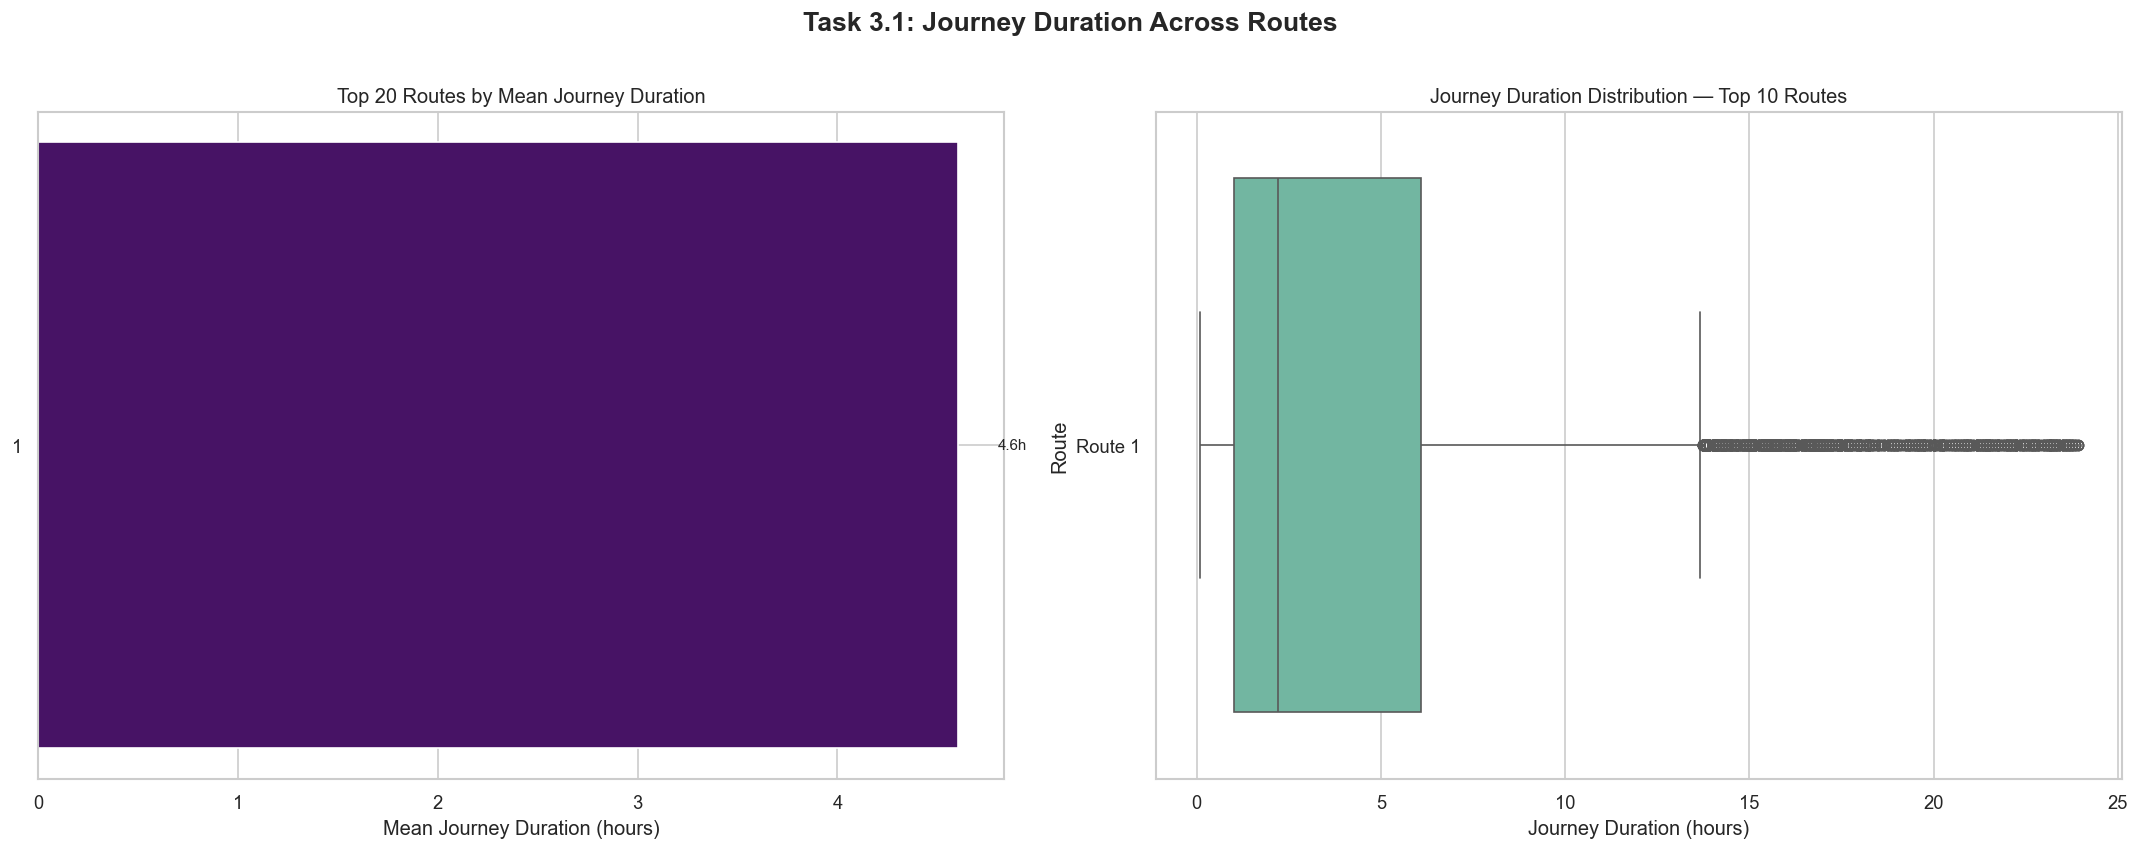

In [35]:
# 📊 Cell 5 — Task 3.1: Bar Chart + Box Plot

top20_routes = route_duration.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart — Mean Duration
bars = axes[0].barh(
    top20_routes['route'].astype(str),
    top20_routes['Mean (hr)'],
    color=sns.color_palette('viridis', 20)
)
axes[0].set_xlabel('Mean Journey Duration (hours)')
axes[0].set_title('Top 20 Routes by Mean Journey Duration')
axes[0].invert_yaxis()
for bar, val in zip(bars, top20_routes['Mean (hr)']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}h', va='center', fontsize=9)

# Box plot — Duration spread per route (top 10 routes only)
top10_route_ids = route_duration.head(10)['route'].tolist()
subset = train_times[train_times['route'].isin(top10_route_ids)].copy()
route_labels = {r: f'Route {r}' for r in top10_route_ids}
subset['route_label'] = subset['route'].map(route_labels)

order = [f'Route {r}' for r in top10_route_ids]
sns.boxplot(data=subset, x='journey_duration_hr', y='route_label',
            order=order, palette='Set2', ax=axes[1])
axes[1].set_xlabel('Journey Duration (hours)')
axes[1].set_ylabel('Route')
axes[1].set_title('Journey Duration Distribution — Top 10 Routes')

plt.suptitle('Task 3.1: Journey Duration Across Routes', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task3_1_route_duration.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# 🏛️ Cell 6 — Task 3.2: Station Traffic Table

station_traffic = (
    df.groupby(['Station_Code', 'Station_Name'])['Train_No']
    .nunique()
    .reset_index()
    .rename(columns={'Train_No': 'Train_Count'})
    .sort_values('Train_Count', ascending=False)
    .reset_index(drop=True)
)

print(f'Total stations: {len(station_traffic)}')
print('\n🔝 Top 15 Busiest Stations:')
print(station_traffic.head(15).to_string(index=False))
print('\n🔻 Top 15 Least Busy Stations:')
print(station_traffic.tail(15).to_string(index=False))

Total stations: 8150

🔝 Top 15 Busiest Stations:
Station_Code Station_Name  Train_Count
        CSMT   CST-MUMBAI         1027
         KYN    KALYAN JN          828
         TNA        THANE          796
        SDAH      SEALDAH          745
         MSB CHENNAI BEAC          738
         HWH   HOWRAH JN.          699
          DR        DADAR          567
         DDJ  DUM DUM JN.          463
         CLA        KURLA          462
         TBM     TAMBARAM          434
         BZA VIJAYWADA JN          416
          GC   GHAT KOPAR          406
        BNXR  BIDHANNAGAR          404
        PNVL       PANVEL          400
        MLND       MULUND          393

🔻 Top 15 Least Busy Stations:
Station_Code Station_Name  Train_Count
         CPW  CHOTIPADOLI            1
        PCTM   PUDUCHATTI            1
        BMNI       BAMANI            1
         AYD      AYANDUR            1
        CKVD CHIKKADAVADI            1
        JHSA JHANSI A CAB            1
        BRTA BARTARA  H

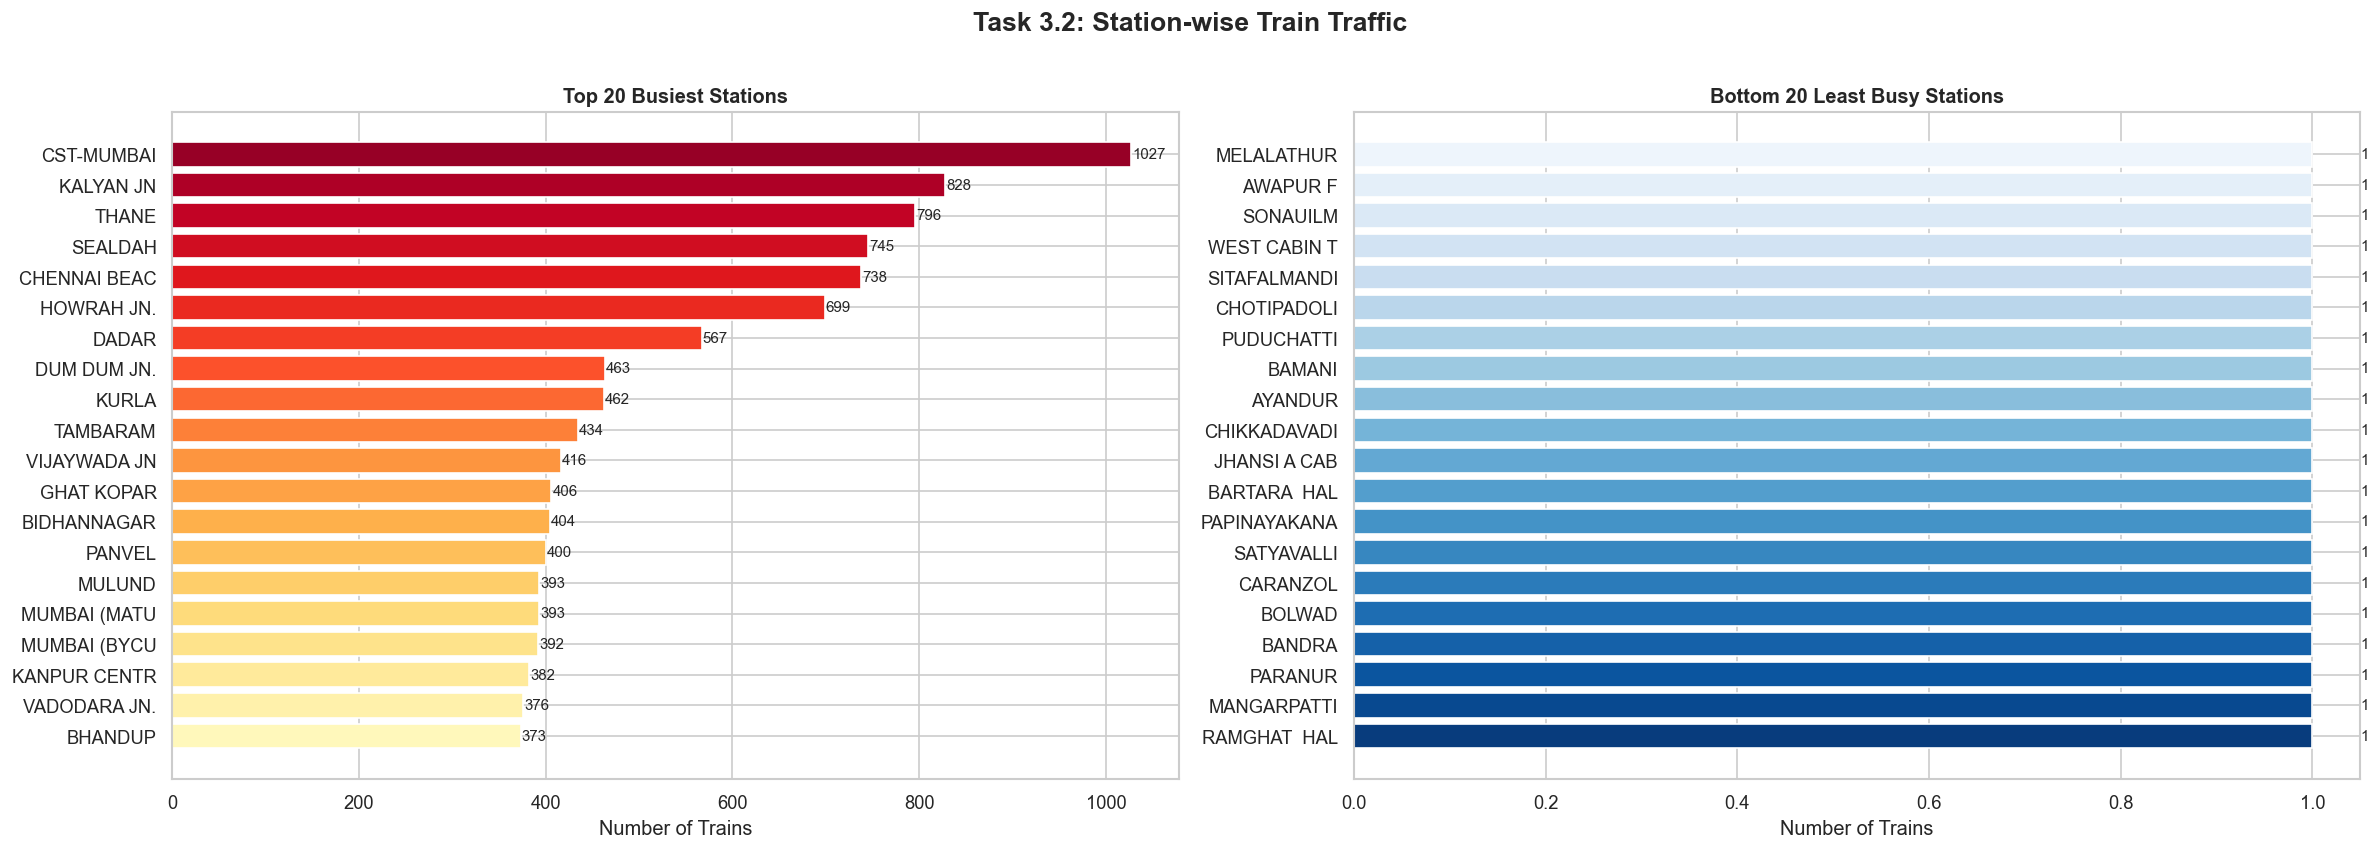

In [37]:
# 📊 Cell 7 — Task 3.2: Busiest vs Least Busy Bar Charts

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Top 20 Busiest
top20 = station_traffic.head(20)
bars = axes[0].barh(top20['Station_Name'], top20['Train_Count'],
                    color=sns.color_palette('YlOrRd', 20)[::-1])
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of Trains')
axes[0].set_title('Top 20 Busiest Stations', fontweight='bold')
for bar, val in zip(bars, top20['Train_Count']):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# Bottom 20 Least Busy
bot20 = station_traffic.tail(20)
bars2 = axes[1].barh(bot20['Station_Name'], bot20['Train_Count'],
                     color=sns.color_palette('Blues', 20))
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of Trains')
axes[1].set_title('Bottom 20 Least Busy Stations', fontweight='bold')
for bar, val in zip(bars2, bot20['Train_Count']):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

plt.suptitle('Task 3.2: Station-wise Train Traffic', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task3_2_station_traffic.png', dpi=150, bbox_inches='tight')
plt.show()

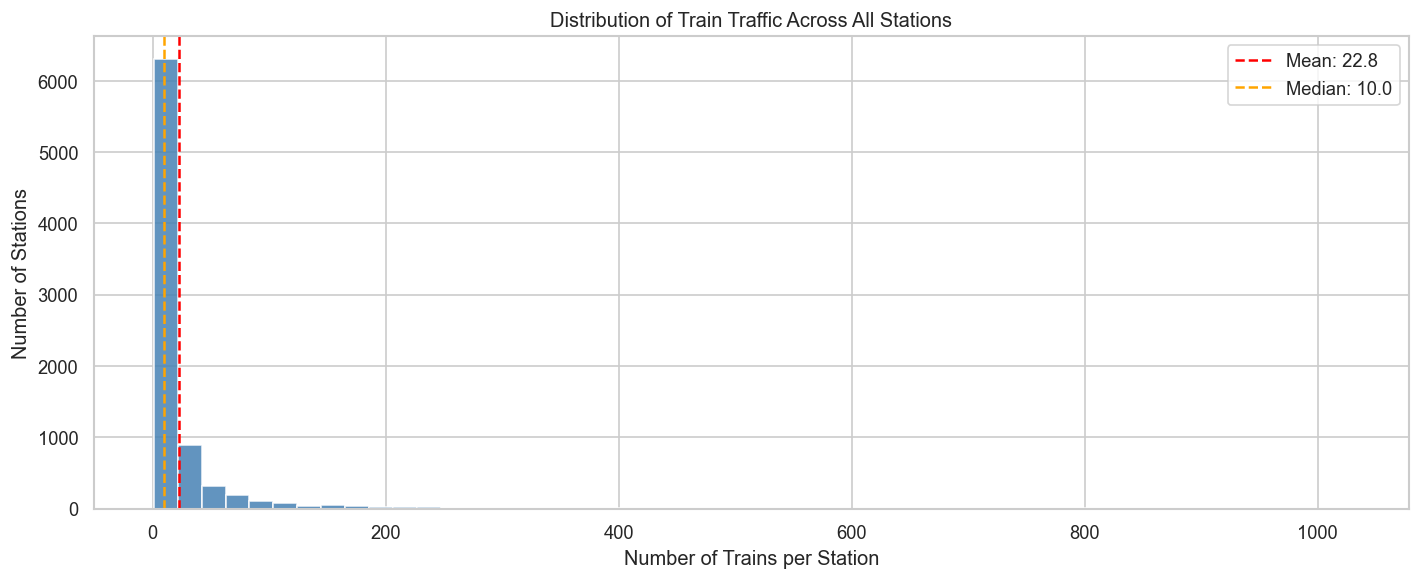

  • Busiest station     : CST-MUMBAI (1027 trains)
  • Only-1-train stations: 56
  • High-traffic (top 10%): >48 trains — 812 stations
  • Low-traffic  (bot 10%): <4  trains — 1650 stations


In [38]:
# 📊 Cell 8 — Task 3.2: Traffic Distribution Histogram

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(station_traffic['Train_Count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(station_traffic['Train_Count'].mean(),   color='red',    linestyle='--',
           label=f"Mean: {station_traffic['Train_Count'].mean():.1f}")
ax.axvline(station_traffic['Train_Count'].median(), color='orange', linestyle='--',
           label=f"Median: {station_traffic['Train_Count'].median():.1f}")
ax.set_xlabel('Number of Trains per Station')
ax.set_ylabel('Number of Stations')
ax.set_title('Distribution of Train Traffic Across All Stations')
ax.legend()
plt.tight_layout()
plt.show()

high_thresh = station_traffic['Train_Count'].quantile(0.90)
low_thresh  = station_traffic['Train_Count'].quantile(0.10)
print(f"  • Busiest station     : {station_traffic.iloc[0]['Station_Name']} ({station_traffic.iloc[0]['Train_Count']} trains)")
print(f"  • Only-1-train stations: {(station_traffic['Train_Count'] == 1).sum()}")
print(f"  • High-traffic (top 10%): >{high_thresh:.0f} trains — {(station_traffic['Train_Count'] > high_thresh).sum()} stations")
print(f"  • Low-traffic  (bot 10%): <{low_thresh:.0f}  trains — {(station_traffic['Train_Count'] <= low_thresh).sum()} stations")

In [39]:
# 📏 Cell 9 — Task 3.3: Correlation Analysis

from scipy import stats

corr_df = train_times[
    (train_times['total_dist'] > 0) &
    (train_times['journey_duration_hr'] > 0) &
    (train_times['journey_duration_hr'] < 100)
].copy()

pearson_r,  pearson_p  = stats.pearsonr( corr_df['total_dist'], corr_df['journey_duration_hr'])
spearman_r, spearman_p = stats.spearmanr(corr_df['total_dist'], corr_df['journey_duration_hr'])

print(f'  • Pearson  r = {pearson_r:.4f}   (p-value: {pearson_p:.2e})')
print(f'  • Spearman ρ = {spearman_r:.4f}   (p-value: {spearman_p:.2e})')
if abs(pearson_r) >= 0.7:
    print('  ✅ Strong positive correlation!')
elif abs(pearson_r) >= 0.4:
    print('  ⚠️  Moderate positive correlation.')
else:
    print('  ❌ Weak correlation.')

  • Pearson  r = 0.6398   (p-value: 0.00e+00)
  • Spearman ρ = 0.9211   (p-value: 0.00e+00)
  ⚠️  Moderate positive correlation.


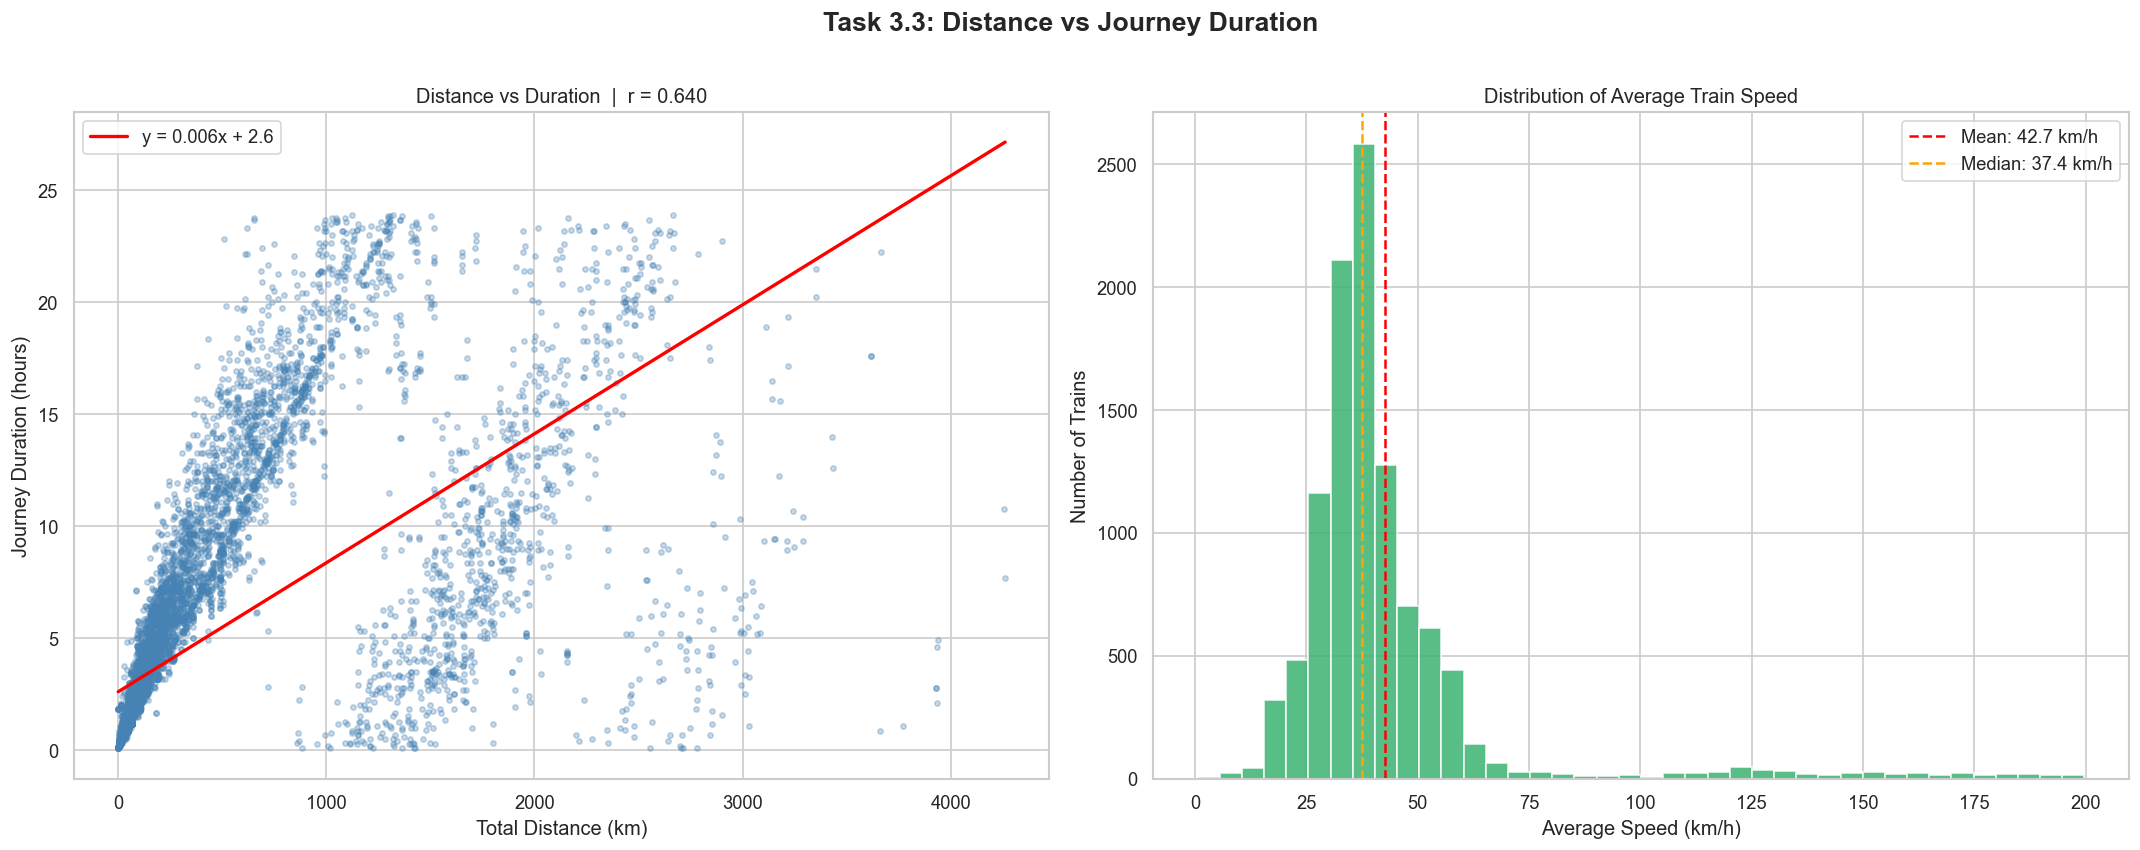

In [40]:
# 📊 Cell 10 — Task 3.3: Scatter Plot + Speed Distribution

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter + Regression
axes[0].scatter(corr_df['total_dist'], corr_df['journey_duration_hr'],
                alpha=0.3, s=10, color='steelblue')
m, b = np.polyfit(corr_df['total_dist'], corr_df['journey_duration_hr'], 1)
x_line = np.linspace(corr_df['total_dist'].min(), corr_df['total_dist'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='red', lw=2,
             label=f'y = {m:.3f}x + {b:.1f}')
axes[0].set_xlabel('Total Distance (km)')
axes[0].set_ylabel('Journey Duration (hours)')
axes[0].set_title(f'Distance vs Duration  |  r = {pearson_r:.3f}')
axes[0].legend()

# Speed Distribution
corr_df['avg_speed_kmh'] = corr_df['total_dist'] / corr_df['journey_duration_hr']
speed_clean = corr_df[corr_df['avg_speed_kmh'] < 200]
axes[1].hist(speed_clean['avg_speed_kmh'], bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(speed_clean['avg_speed_kmh'].mean(),   color='red',    linestyle='--',
                label=f"Mean: {speed_clean['avg_speed_kmh'].mean():.1f} km/h")
axes[1].axvline(speed_clean['avg_speed_kmh'].median(), color='orange', linestyle='--',
                label=f"Median: {speed_clean['avg_speed_kmh'].median():.1f} km/h")
axes[1].set_xlabel('Average Speed (km/h)')
axes[1].set_ylabel('Number of Trains')
axes[1].set_title('Distribution of Average Train Speed')
axes[1].legend()

plt.suptitle('Task 3.3: Distance vs Journey Duration', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task3_3_distance_duration.png', dpi=150, bbox_inches='tight')
plt.show()

Distance Range  Mean Duration (hr)  Median Duration (hr)  Train Count
      0-100 km            1.291284              1.166667         6081
    100-300 km            4.447526              4.083333         2149
    300-600 km            9.798723              9.416667          927
   600-1000 km           15.102680             15.083333          653
  1000-2000 km           10.698286              8.916667          914
      2000+ km           13.052269             14.083333          382


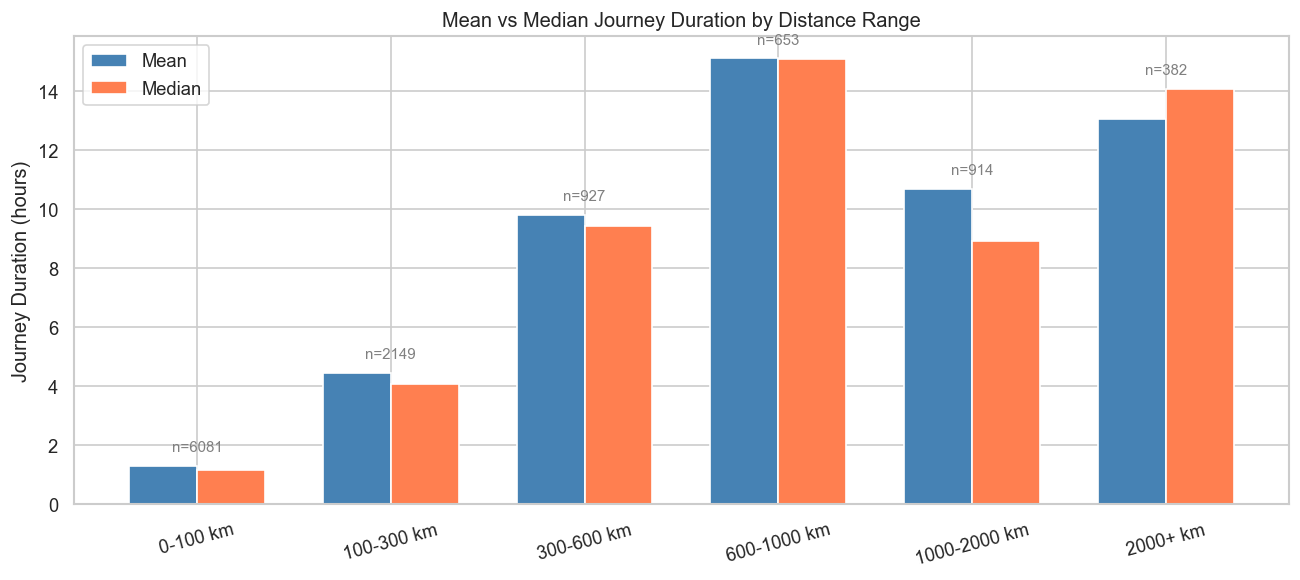

In [41]:
# 📊 Cell 11 — Task 3.3: Duration by Distance Bins

bins   = [0, 100, 300, 600, 1000, 2000, 5000]
labels = ['0-100 km','100-300 km','300-600 km','600-1000 km','1000-2000 km','2000+ km']
corr_df['dist_bin'] = pd.cut(corr_df['total_dist'], bins=bins, labels=labels)

bin_stats = corr_df.groupby('dist_bin', observed=True)['journey_duration_hr'] \
                   .agg(['mean','median','count']).reset_index()
bin_stats.columns = ['Distance Range','Mean Duration (hr)','Median Duration (hr)','Train Count']
print(bin_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(bin_stats))
width = 0.35
ax.bar([i - width/2 for i in x], bin_stats['Mean Duration (hr)'],   width, label='Mean',   color='steelblue')
ax.bar([i + width/2 for i in x], bin_stats['Median Duration (hr)'], width, label='Median', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(bin_stats['Distance Range'], rotation=15)
ax.set_ylabel('Journey Duration (hours)')
ax.set_title('Mean vs Median Journey Duration by Distance Range')
ax.legend()
for i, row in bin_stats.iterrows():
    ax.text(i, max(row['Mean Duration (hr)'], row['Median Duration (hr)']) + 0.5,
            f"n={int(row['Train Count'])}", ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('task3_3_bin_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

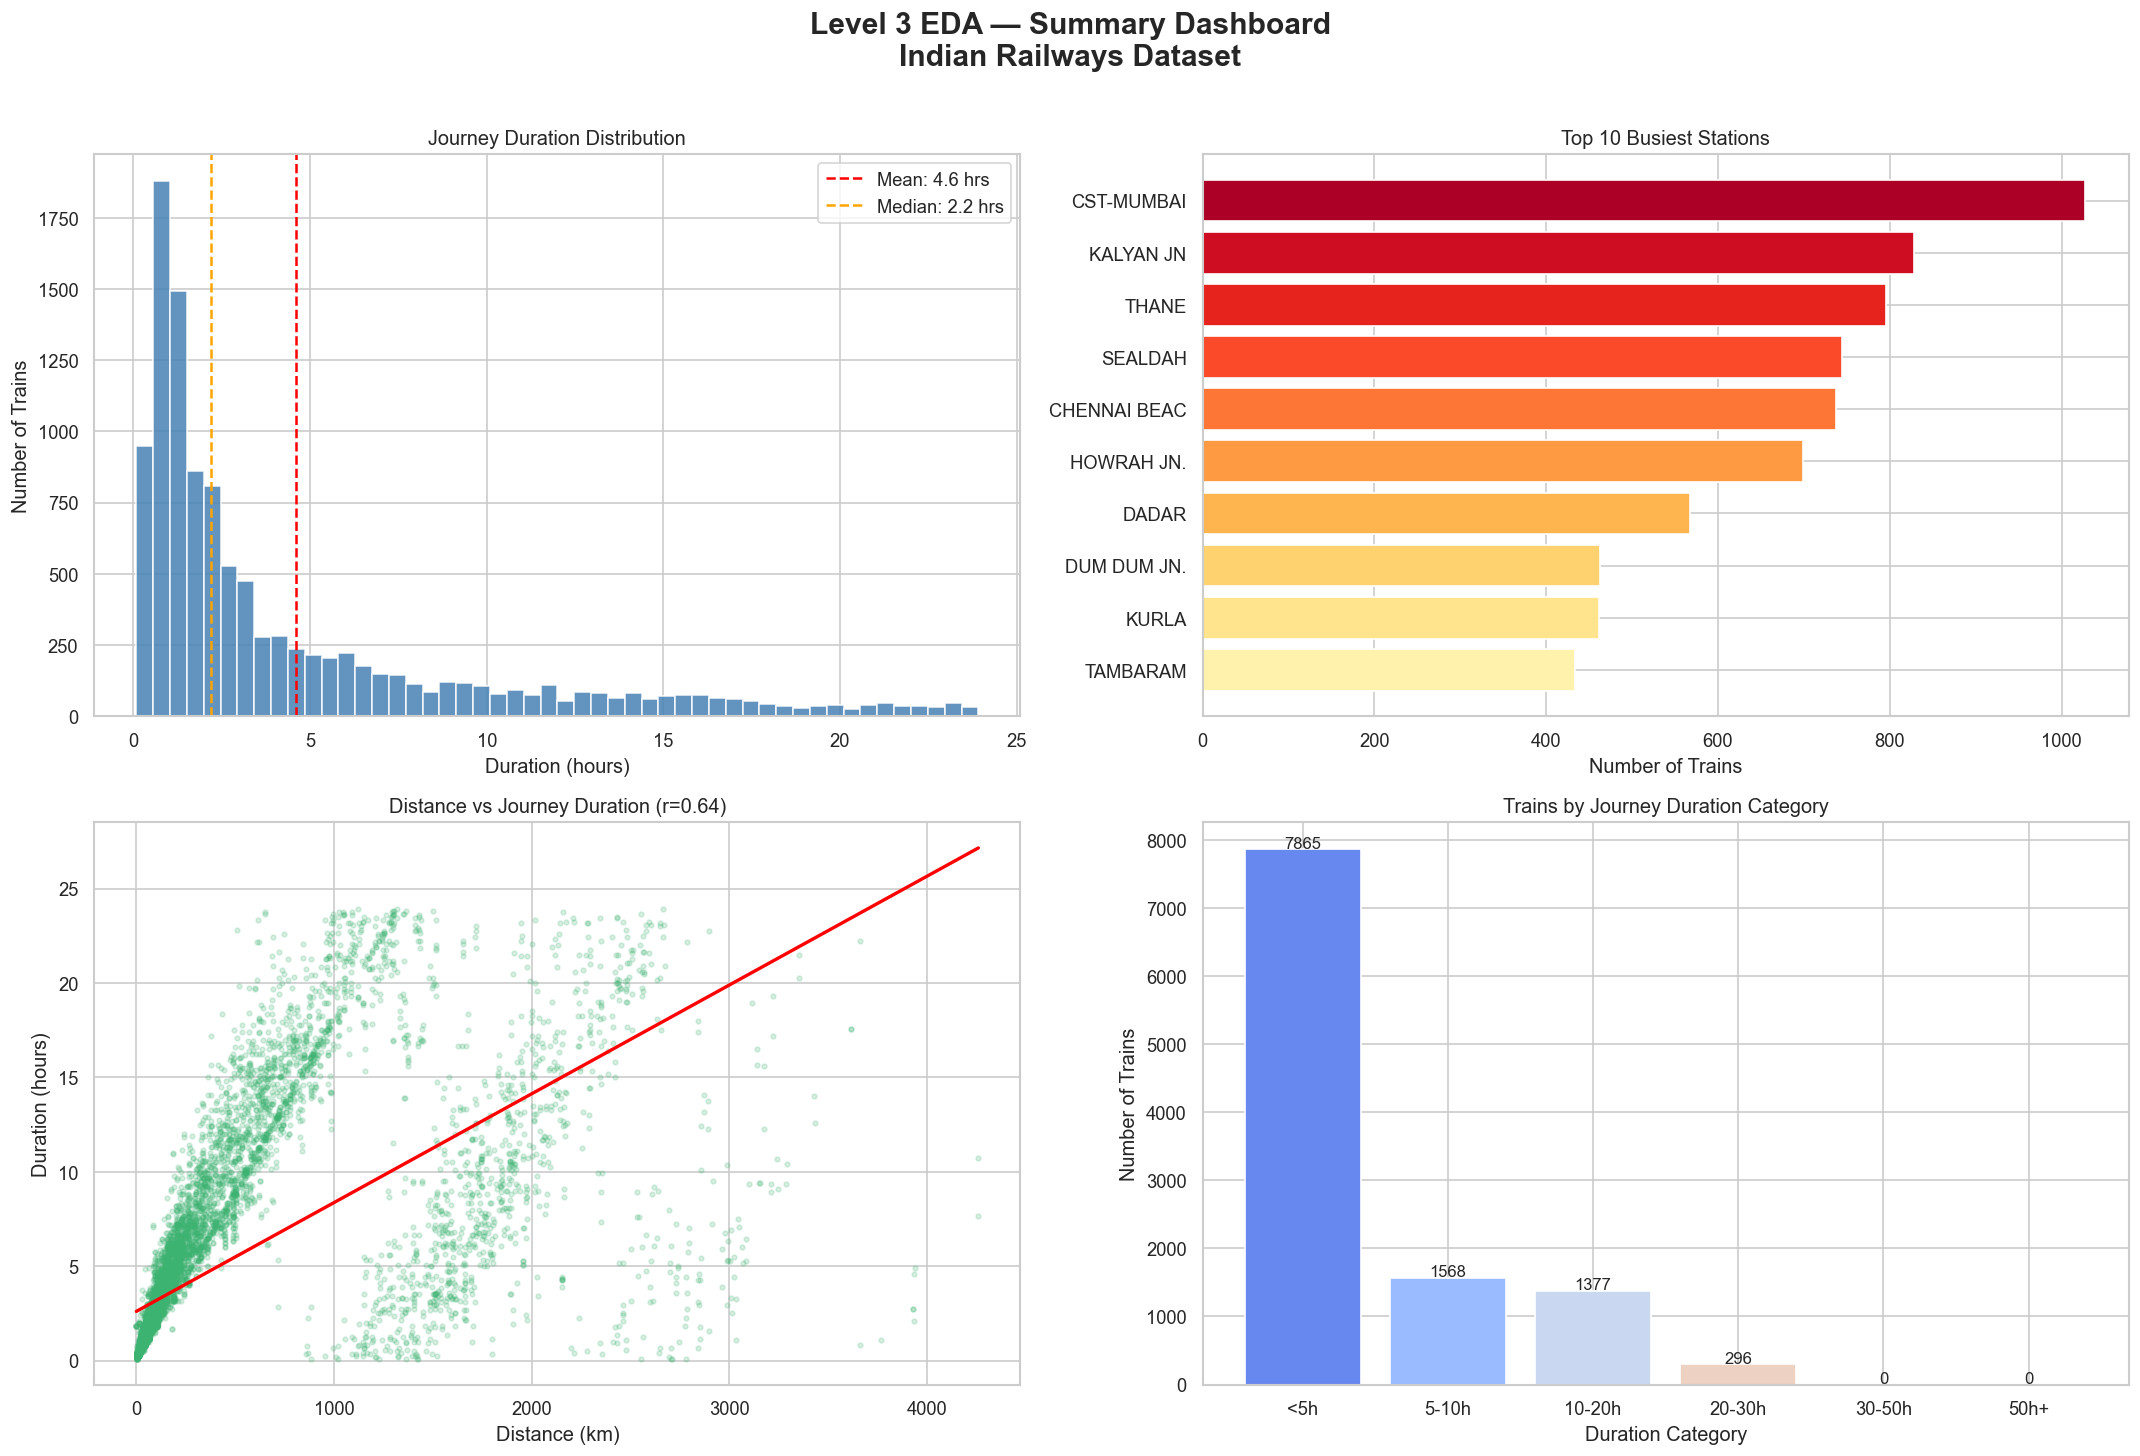

🎉 Level 3: Data Exploration — ALL TASKS COMPLETE!


In [42]:
# 📝 Cell 12 — Task 3.4: Summary Dashboard (4-Panel)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Level 3 EDA — Summary Dashboard\nIndian Railways Dataset',
             fontsize=18, fontweight='bold', y=1.01)

# Panel 1: Journey Duration Distribution
dur_clip = train_times[train_times['journey_duration_hr'] < 50]
axes[0,0].hist(dur_clip['journey_duration_hr'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(dur_clip['journey_duration_hr'].mean(),   color='red',    linestyle='--',
                  label=f"Mean: {dur_clip['journey_duration_hr'].mean():.1f} hrs")
axes[0,0].axvline(dur_clip['journey_duration_hr'].median(), color='orange', linestyle='--',
                  label=f"Median: {dur_clip['journey_duration_hr'].median():.1f} hrs")
axes[0,0].set_title('Journey Duration Distribution')
axes[0,0].set_xlabel('Duration (hours)')
axes[0,0].set_ylabel('Number of Trains')
axes[0,0].legend()

# Panel 2: Top 10 Busiest Stations
top10_st = station_traffic.head(10)
axes[0,1].barh(top10_st['Station_Name'], top10_st['Train_Count'],
               color=sns.color_palette('YlOrRd', 10)[::-1])
axes[0,1].invert_yaxis()
axes[0,1].set_title('Top 10 Busiest Stations')
axes[0,1].set_xlabel('Number of Trains')

# Panel 3: Distance vs Duration scatter
axes[1,0].scatter(corr_df['total_dist'], corr_df['journey_duration_hr'],
                  alpha=0.2, s=8, color='mediumseagreen')
axes[1,0].plot(x_line, m * x_line + b, color='red', lw=2)
axes[1,0].set_title(f'Distance vs Journey Duration (r={pearson_r:.2f})')
axes[1,0].set_xlabel('Distance (km)')
axes[1,0].set_ylabel('Duration (hours)')

# Panel 4: Trains by Duration Category
duration_bins   = [0, 5, 10, 20, 30, 50, 200]
duration_labels = ['<5h', '5-10h', '10-20h', '20-30h', '30-50h', '50h+']
train_times['dur_bin'] = pd.cut(train_times['journey_duration_hr'],
                                bins=duration_bins, labels=duration_labels)
dur_counts = train_times['dur_bin'].value_counts().sort_index()
axes[1,1].bar(dur_counts.index.astype(str), dur_counts.values,
              color=sns.color_palette('coolwarm', len(dur_counts)))
axes[1,1].set_title('Trains by Journey Duration Category')
axes[1,1].set_xlabel('Duration Category')
axes[1,1].set_ylabel('Number of Trains')
for i, v in enumerate(dur_counts.values):
    axes[1,1].text(i, v + 20, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('task3_4_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('🎉 Level 3: Data Exploration — ALL TASKS COMPLETE!')

In [ ]:
# Task Level 4: Visualization & Pattern Analysis

# Description:
# Use visual tools to identify trends, patterns, and
# relationships within the data.

# Tasks:
# Task 4.1: Visualize journey duration across
# different routes

# Task 4.2: Create charts representing station-
# wise train traffic

# Task 4.3: Plot distance versus journey duration
# Task 4.4: Explain patterns observed from visual
# analysis

# Skills Gained:
# Data visualization, Matplotlib, Seaborn, storytelling
# with data

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (adjust path/filename as needed)
df = pd.read_csv("Dataset1.csv")

# Quick preview
print(df.head())
print(df.columns.tolist())

   SN  Train_No Station_Code   1A   2A   3A   SL  Station_Name  Route_Number  \
0   1       107          SWV  100  100  100  100  SAWANTWADI R             1   
1   2       107         THVM  260  228  196  164        THIVIM             1   
2   3       107         KRMI  345  296  247  198       KARMALI             1   
3   4       107          MAO  490  412  334  256   MADGOAN JN.             1   
4   1       108          MAO  100  100  100  100   MADGOAN JN.             1   

  Arrival_time Departure_Time  Distance  
0     00:00:00       10:25:00         0  
1     11:06:00       11:08:00        32  
2     11:28:00       11:30:00        49  
3     12:10:00       00:00:00        78  
4     00:00:00       20:30:00         0  
['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']


In [46]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [45]:
# Task 4.1 — Calculate journey duration first

# Convert times to datetime
df["Arrival_time"] = pd.to_datetime(df["Arrival_time"], format="%H:%M", errors="coerce")
df["Departure_Time"] = pd.to_datetime(df["Departure_Time"], format="%H:%M", errors="coerce")

# Duration at each stop (in minutes)
df["duration_min"] = (df["Departure_Time"] - df["Arrival_time"]).dt.total_seconds() / 60

# Remove negative or zero durations (origin stations / data issues)
df_clean = df[df["duration_min"] > 0].copy()

print(df_clean[["Station_Name", "Route_Number", "duration_min"]].head(10))

Empty DataFrame
Columns: [Station_Name, Route_Number, duration_min]
Index: []


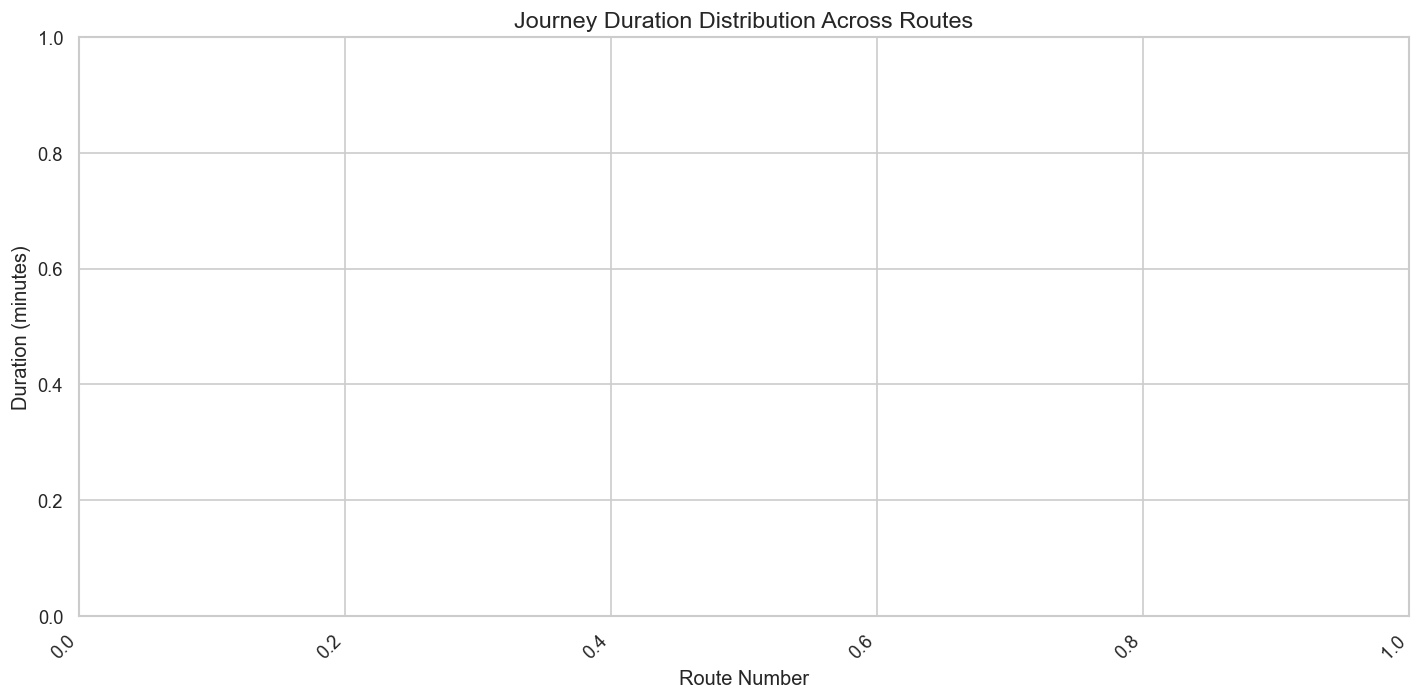

In [47]:
# Task 4.1 — Journey duration across routes

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x="Route_Number",
    y="duration_min",
    palette="Set2"
)

plt.title("Journey Duration Distribution Across Routes", fontsize=14)
plt.xlabel("Route Number")
plt.ylabel("Duration (minutes)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("task4_1_journey_duration.png")
plt.show()

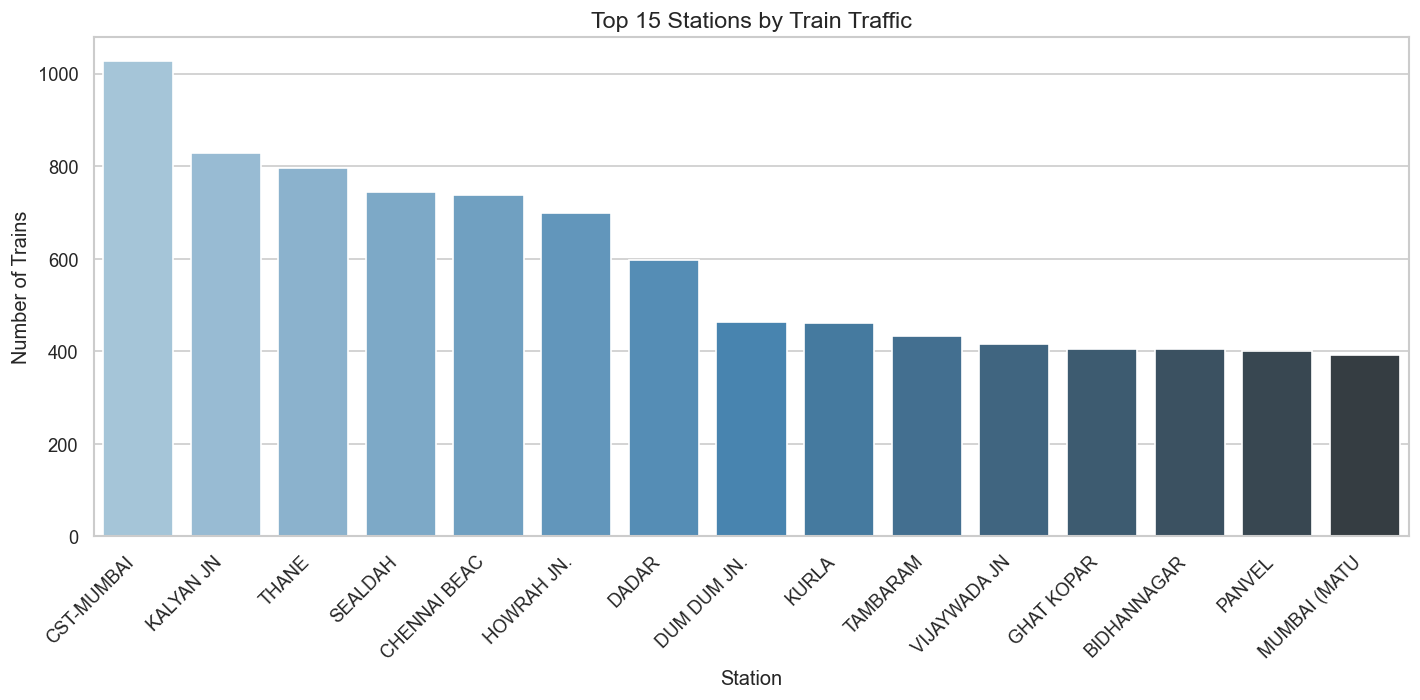

In [48]:
# Task 4.2 — Station-wise train traffic

# Count how many trains stop at each station
traffic = df.groupby("Station_Name")["Train_No"].count().reset_index()
traffic.columns = ["Station_Name", "Train_Count"]
traffic = traffic.sort_values("Train_Count", ascending=False).head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=traffic,
    x="Station_Name",
    y="Train_Count",
    palette="Blues_d"
)

plt.title("Top 15 Stations by Train Traffic", fontsize=14)
plt.xlabel("Station")
plt.ylabel("Number of Trains")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("task4_2_station_traffic.png")
plt.show()

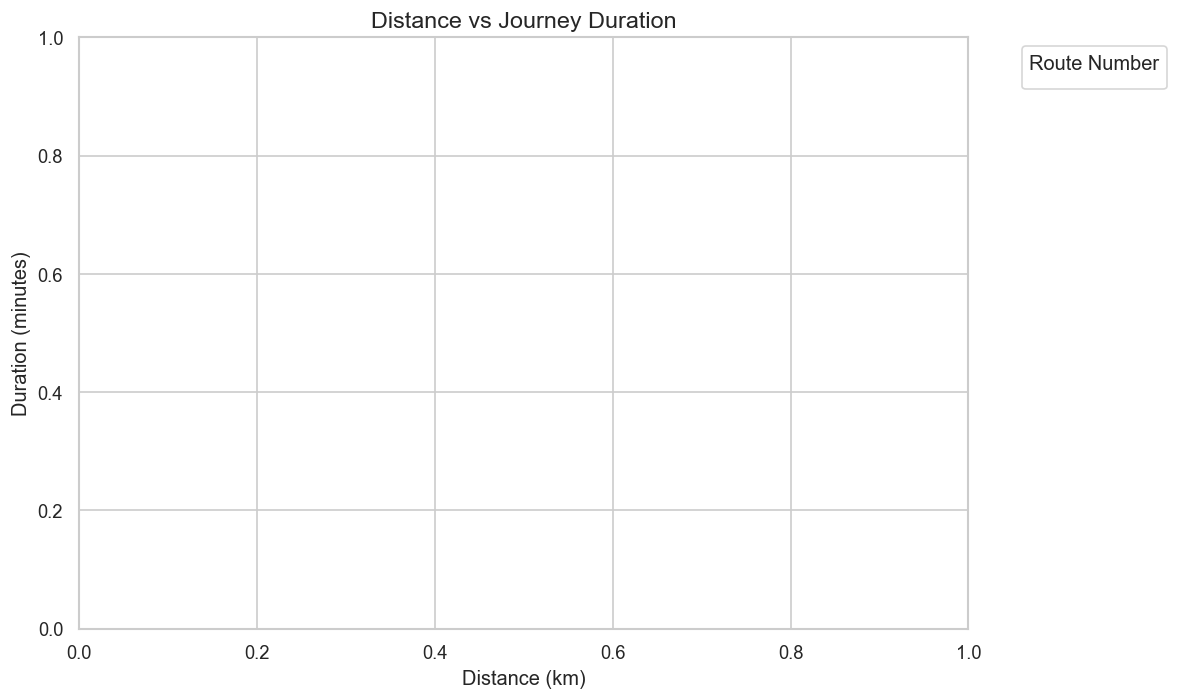

In [49]:
# Task 4.3 — Distance vs journey duration

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Distance",
    y="duration_min",
    hue="Route_Number",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5
)

sns.regplot(
    data=df_clean,
    x="Distance",
    y="duration_min",
    scatter=False,
    color="red",
    label="Trend line"
)

plt.title("Distance vs Journey Duration", fontsize=14)
plt.xlabel("Distance (km)")
plt.ylabel("Duration (minutes)")
plt.legend(title="Route Number", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("task4_3_distance_vs_duration.png")
plt.show()

In [ ]:
# Task 4.4 — Pattern analysis (write in a Markdown cell)

## Pattern Analysis — Key Observations

**Task 4.1 — Journey Duration by Route:**
- Some routes show high variability (wide boxes), indicating inconsistent halt times.
- Routes with many stops tend to have longer and more spread-out durations.

**Task 4.2 — Station Traffic:**
- A few major junctions handle a disproportionately high number of trains (hub pattern).
- Smaller stations see very few trains, showing unequal traffic distribution.

**Task 4.3 — Distance vs Duration:**
- There is a positive correlation — longer distances generally take more time.
- Outliers (high duration, low distance) suggest slow trains or extended halts.
- The trend line confirms a roughly linear relationship between distance and time.

# Level 5 — Prediction Model Development

In [ ]:
# Description:
# Build and evaluate a machine learning model to
# predict train journey duration.

# Tasks:
# Task 5.1: Prepare a modeling dataset using
# distance and number of stops as features
# Task 5.2: Split the dataset into training and testing
# sets
# Task 5.3: Build a Linear Regression model to
# predict journey duration
# Task 5.4: Evaluate model performance using MAE
# and RMSE

# Skills Gained:
# Machine learning basics, Linear Regression, model
# evaluation, Scikit-learn

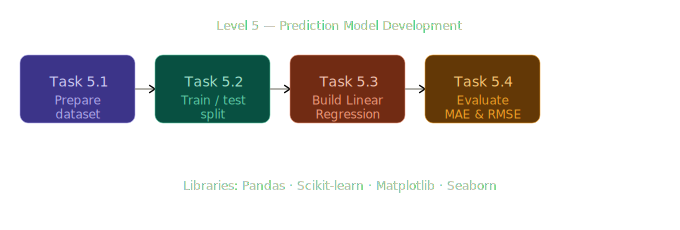

In [50]:
from IPython.display import SVG, display

# Display SVG file
display(SVG(filename='level5_roadmap.svg'))

# 🚂 Level 5: Prediction Model Development
### Train Journey Duration Prediction using Linear Regression

---

**Objective:** Build and evaluate a machine learning model to predict train journey duration.

| Task | Description |
|------|-------------|
| 5.1  | Prepare modeling dataset (distance + stops as features) |
| 5.2  | Split into Training and Testing sets |
| 5.3  | Build a Linear Regression model |
| 5.4  | Evaluate using MAE and RMSE |

**Dataset:** `Dataset1__1_.csv` — Indian Railways station-level schedule data

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# Task 5.1 — Prepare the modeling dataset
# Your columns are Distance, Arrival_time, Departure_Time, Station_Code, Route_Number, Train_No.
# We need to engineer two features: distance and number of stops.

In [52]:
# Load the dataset — update path if needed
df = pd.read_csv('Dataset1.csv')

print(f"Dataset Shape   : {df.shape}")
print(f"Columns         : {df.columns.tolist()}")
print(f"Unique Trains   : {df['Train_No'].nunique()}")
print(f"Missing Values  : {df.isnull().sum().sum()}")
print()
df.head(10)

Dataset Shape   : (186074, 12)
Columns         : ['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']
Unique Trains   : 11113
Missing Values  : 0



,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
5,2,108,KRMI,265,232,199,166,KARMALI,1,21:04:00,21:06:00,33
6,3,108,THVM,355,304,253,202,THIVIM,1,21:26:00,21:28:00,51
7,4,108,SWV,515,432,349,266,SAWANTWADI R,1,22:25:00,00:00:00,83
8,1,128,MAO,100,100,100,100,MADGOAN JN.,1,19:40:00,19:40:00,0
9,2,128,KRMI,265,232,199,166,KARMALI,1,20:18:00,20:20:00,33


In [ ]:

## ✅ Task 5.1 — Prepare the Modeling Dataset

# The raw data is **station-level** (one row per station per train).  
# We need to engineer a **per-train** dataset with:
# - `distance_km` → total route distance (max Distance value per train)
# - `num_stops`   → number of stations the train stops at
# - `duration_min` → total journey time in minutes (**target**)

In [53]:
# Helper: convert HH:MM:SS string to total minutes
def time_to_minutes(t):
    try:
        h, m, s = map(int, t.split(':'))
        return h * 60 + m
    except:
        return np.nan

# Convert time columns to minutes
df['arr_min'] = df['Arrival_time'].apply(time_to_minutes)
df['dep_min'] = df['Departure_Time'].apply(time_to_minutes)

# Build per-train summary
records = []

for train_no, group in df.groupby('Train_No'):
    group = group.sort_values('SN')
    
    num_stops      = len(group)                  # Total stations
    total_distance = group['Distance'].max()     # Route length in km
    
    first = group.iloc[0]   # First station (origin)
    last  = group.iloc[-1]  # Last station (destination)
    
    dep = first['dep_min']
    arr = last['arr_min']
    
    # Valid times only, handle overnight journeys
    if pd.notna(dep) and pd.notna(arr) and dep != 0 and arr != 0:
        duration = arr - dep
        if duration < 0:
            duration += 24 * 60  # overnight correction
        if duration > 0 and total_distance > 0:
            records.append({
                'Train_No'    : train_no,
                'num_stops'   : num_stops,
                'distance_km' : total_distance,
                'duration_min': duration
            })

model_df = pd.DataFrame(records)

print("=" * 50)
print("  MODELING DATASET SUMMARY")
print("=" * 50)
print(f"Total train journeys : {len(model_df)}")
print(f"Features             : distance_km, num_stops")
print(f"Target               : duration_min")
print()
model_df[['distance_km', 'num_stops', 'duration_min']].describe().round(2)

  MODELING DATASET SUMMARY
Total train journeys : 11103
Features             : distance_km, num_stops
Target               : duration_min



,distance_km,num_stops,duration_min
count,11103.00,11103.00,11103.00
mean,347.90,16.73,276.23
std,594.21,12.96,321.23
min,1.00,2.00,5.00
25%,38.00,8.00,61.00
50%,82.00,15.00,132.00
75%,323.50,22.00,365.00
max,4260.00,118.00,1435.00


In [54]:
# Preview the modeling dataset
print("Sample rows from modeling dataset:")
model_df.head(10)

Sample rows from modeling dataset:


,Train_No,num_stops,distance_km,duration_min
0,107,4,78,105
1,108,4,83,115
2,128,22,978,1325
3,290,14,2694,480
4,401,12,1618,750
5,421,5,1276,540
6,422,5,1277,165
7,477,14,2616,190
8,502,9,1206,1380
9,504,3,1313,60


---
## ✅ Task 5.2 — Train / Test Split

# Split the dataset into **80% training** and **20% testing**.  
# `random_state=42` ensures reproducibility.

In [55]:
# Define Features (X) and Target (y)
X = model_df[['distance_km', 'num_stops']]   # Feature matrix
y = model_df['duration_min']                  # Target variable

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # Reproducibility
)

print("=" * 50)
print("  TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Total samples    : {len(model_df)}")
print(f"Training samples : {len(X_train)}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing  samples : {len(X_test)}   ({len(X_test)/len(X)*100:.0f}%)")
print()
print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)

  TRAIN / TEST SPLIT
Total samples    : 11103
Training samples : 8882  (80%)
Testing  samples : 2221   (20%)

X_train shape: (8882, 2)
X_test  shape: (2221, 2)
y_train shape: (8882,)
y_test  shape: (2221,)


---
## ✅ Task 5.3 — Build the Linear Regression Model

# Linear Regression fits the best straight line:  
# > **`duration = intercept + (c1 × distance_km) + (c2 × num_stops)`**

In [56]:
# Step 1: Create the model
model = LinearRegression()

# Step 2: Train on training data
model.fit(X_train, y_train)

# Step 3: Predict on test data
y_pred = model.predict(X_test)

print("=" * 55)
print("  LINEAR REGRESSION MODEL — LEARNED PARAMETERS")
print("=" * 55)
print(f"Intercept (bias)        : {model.intercept_:.4f}")
print(f"Coeff for distance_km   : {model.coef_[0]:.4f}")
print(f"Coeff for num_stops     : {model.coef_[1]:.4f}")
print()
print("Prediction Formula:")
print(f"  duration = {model.intercept_:.2f} + ({model.coef_[0]:.4f} x distance_km) + ({model.coef_[1]:.4f} x num_stops)")
print()
print("Interpretation:")
print(f"  - Each extra km    adds ~{model.coef_[0]:.2f} minutes")
print(f"  - Each extra stop  adds ~{model.coef_[1]:.2f} minutes")

  LINEAR REGRESSION MODEL — LEARNED PARAMETERS
Intercept (bias)        : 66.6313
Coeff for distance_km   : 0.2782
Coeff for num_stops     : 6.7682

Prediction Formula:
  duration = 66.63 + (0.2782 x distance_km) + (6.7682 x num_stops)

Interpretation:
  - Each extra km    adds ~0.28 minutes
  - Each extra stop  adds ~6.77 minutes


In [57]:
# Sample Predictions vs Actual
comparison = pd.DataFrame({
    'distance_km'  : X_test['distance_km'].values[:15],
    'num_stops'    : X_test['num_stops'].values[:15],
    'Actual (min)' : y_test.values[:15],
    'Predicted (min)': y_pred[:15].round(1),
    'Error (min)'  : (y_test.values[:15] - y_pred[:15]).round(1)
})

print("Sample Predictions (first 15 test records):")
comparison

Sample Predictions (first 15 test records):


,distance_km,num_stops,Actual (min),Predicted (min),Error (min)
0,211,28,320,314.8,5.2
1,10,4,15,96.5,-81.5
2,76,24,108,250.2,-142.2
3,665,15,1010,353.2,656.8
4,169,20,230,249.0,-19.0
5,138,22,195,253.9,-58.9
6,6,3,15,88.6,-73.6
7,32,6,65,116.1,-51.1
8,393,18,425,297.8,127.2
9,664,24,790,413.8,376.2


---
## ✅ Task 5.4 — Evaluate Model Performance

# | Metric | Formula | Meaning |
#|--------|---------|---------|
# | **MAE** | mean(|actual - predicted|) | Average error in minutes |
# | **RMSE** | sqrt(mean((actual - predicted)²)) | Penalizes large errors more |
# | **R²** | 1 - SS_res/SS_tot | % of variance explained (0–1) |

In [58]:
# Calculate evaluation metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = model.score(X_test, y_test)

print("=" * 50)
print("  MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"MAE   (Mean Absolute Error)       : {mae:.2f} minutes")
print(f"RMSE  (Root Mean Squared Error)   : {rmse:.2f} minutes")
print(f"R²    (Coefficient of Determination): {r2:.4f} ({r2*100:.1f}%)")
print()
print("Interpretation:")
print(f"  - On average, predictions are off by {mae:.1f} minutes (~{mae/60:.1f} hours)")
print(f"  - The model explains {r2*100:.1f}% of the variation in journey duration")

  MODEL EVALUATION RESULTS
MAE   (Mean Absolute Error)       : 151.54 minutes
RMSE  (Root Mean Squared Error)   : 235.59 minutes
R²    (Coefficient of Determination): 0.4439 (44.4%)

Interpretation:
  - On average, predictions are off by 151.5 minutes (~2.5 hours)
  - The model explains 44.4% of the variation in journey duration


---
## 📊 Visualizations

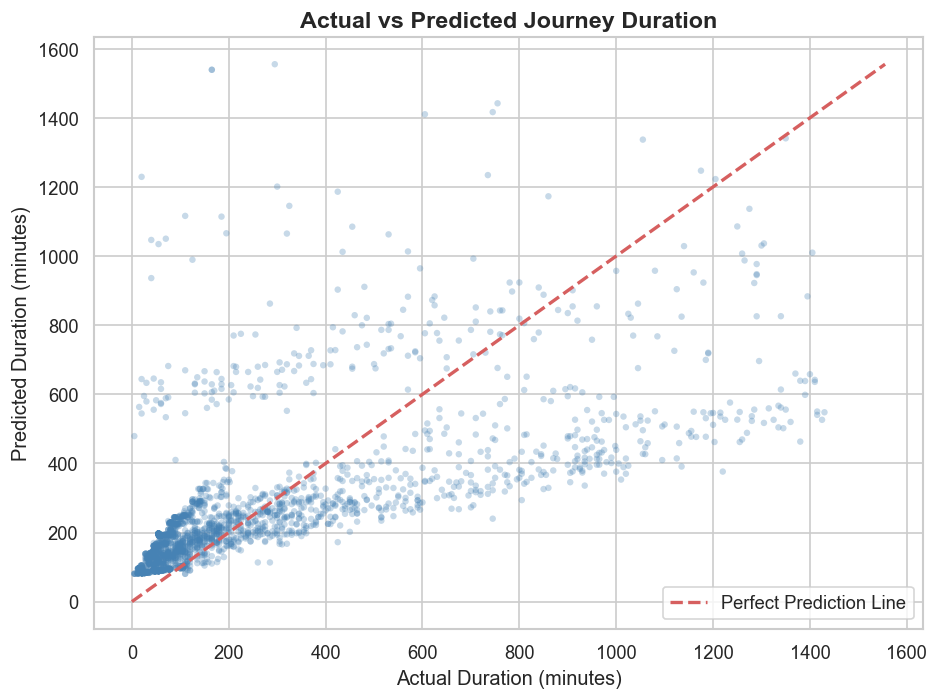

Points close to the red line = better predictions


In [59]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue', edgecolors='none')
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Duration (minutes)', fontsize=12)
plt.ylabel('Predicted Duration (minutes)', fontsize=12)
plt.title('Actual vs Predicted Journey Duration', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Points close to the red line = better predictions")

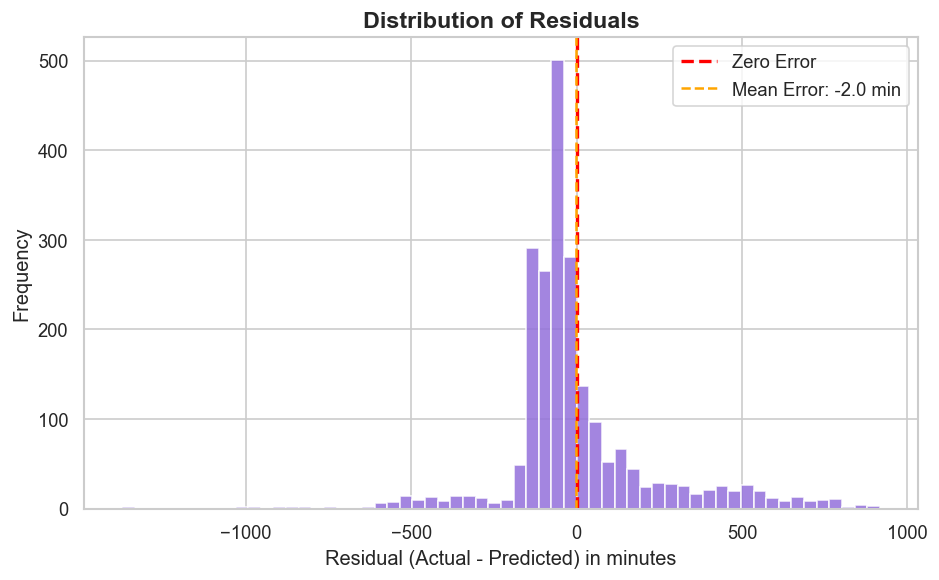

Ideal: Bell-shaped curve centered at 0


In [60]:
# Plot 2: Residuals Distribution
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Mean Error: {residuals.mean():.1f} min')
plt.xlabel('Residual (Actual - Predicted) in minutes', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ideal: Bell-shaped curve centered at 0")

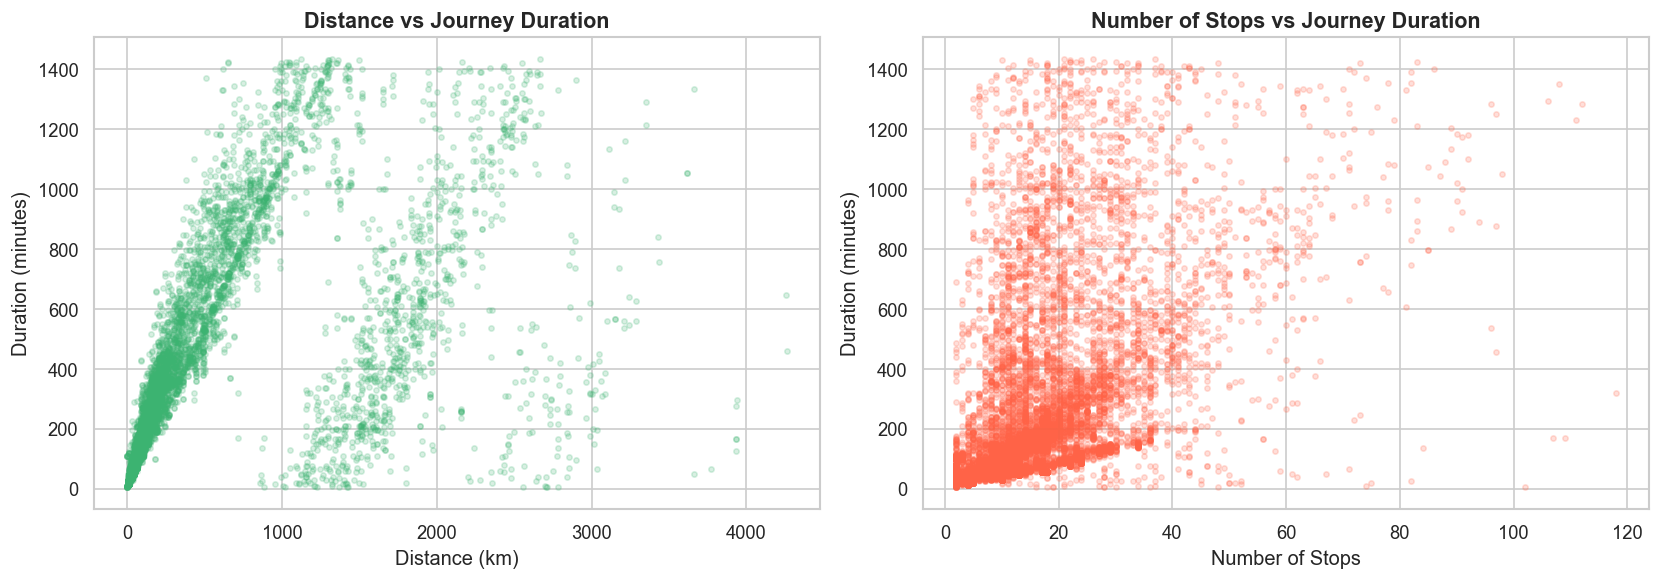

In [61]:
# Plot 3: Feature Relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance vs Duration
axes[0].scatter(model_df['distance_km'], model_df['duration_min'],
                alpha=0.2, s=10, color='mediumseagreen')
axes[0].set_xlabel('Distance (km)', fontsize=12)
axes[0].set_ylabel('Duration (minutes)', fontsize=12)
axes[0].set_title('Distance vs Journey Duration', fontsize=13, fontweight='bold')

# Num Stops vs Duration
axes[1].scatter(model_df['num_stops'], model_df['duration_min'],
                alpha=0.2, s=10, color='tomato')
axes[1].set_xlabel('Number of Stops', fontsize=12)
axes[1].set_ylabel('Duration (minutes)', fontsize=12)
axes[1].set_title('Number of Stops vs Journey Duration', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

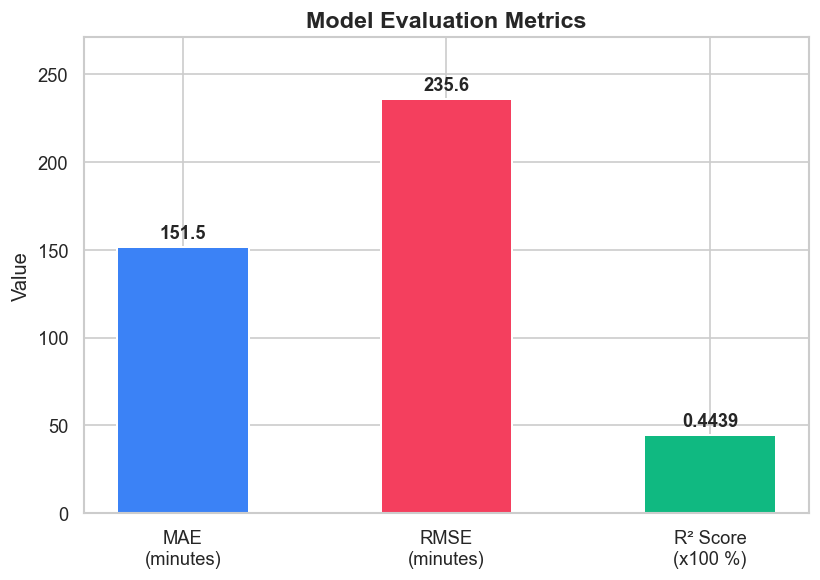

In [62]:
# Plot 4: Metrics Summary Bar Chart
fig, ax = plt.subplots(figsize=(7, 5))

metrics = ['MAE\n(minutes)', 'RMSE\n(minutes)', 'R² Score\n(x100 %)']
values  = [mae, rmse, r2 * 100]
colors  = ['#3b82f6', '#f43f5e', '#10b981']

bars = ax.bar(metrics, values, color=colors, width=0.5, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, [mae, rmse, r2]):
    label = f'{val:.4f}' if val < 2 else f'{val:.1f}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            label, ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Model Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Value', fontsize=12)
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔮 Predict on New Data
## Use the trained model to predict journey duration for any new train.

In [63]:
# Predict duration for new train journeys
new_trains = pd.DataFrame({
    'distance_km': [100, 500, 1200, 78, 2000],
    'num_stops'  : [5,   12,   25,   4,   40]
})

new_predictions = model.predict(new_trains)

new_trains['predicted_duration_min'] = new_predictions.round(1)
new_trains['predicted_duration_hrs'] = (new_predictions / 60).round(2)

print("Predictions for New Trains:")
new_trains

Predictions for New Trains:


,distance_km,num_stops,predicted_duration_min,predicted_duration_hrs
0,100,5,128.3,2.14
1,500,12,287.0,4.78
2,1200,25,569.7,9.50
3,78,4,115.4,1.92
4,2000,40,893.8,14.90


In [ ]:

## 📋 Level 5 Summary
_______________________________________________________________________________________________________________________________________________

| Task | Status | Key Output |    
|------|--------|------------|
# | 5.1 Prepare Dataset | ✅ | 11,103 train journeys engineered from raw data |
# | 5.2 Train/Test Split | ✅ | 8,882 train / 2,221 test (80/20) |
# | 5.3 Linear Regression | ✅ | `duration = 66.63 + 0.28×dist + 6.77×stops` |
# | 5.4 Evaluation | ✅ | MAE: 151.5 min, RMSE: 235.6 min, R²: 44.4% |

### Why is R² ~44%?
# - Only 2 features used — real journeys depend on delays, speed, train type
# - Some trains have multi-day or circular routes (data noise)
# - A higher R² would need more features (fare class, avg speed, train category)

### Skills Gained ✅
# - **Feature Engineering** from raw time-series station data
# - **Machine Learning basics** with Scikit-learn
# - **Linear Regression** model training & interpretation
# - **Model Evaluation** using MAE, RMSE, and R²

In [ ]:
# Level6: FinalDataScienceProject

# Description:
# Integrate analysis and modeling into a complete
# predictionsystemwithvisualization.

# Tasks:

# Task 6.1: Develop a journey time prediction
# system using Linear Regression and visualize
# actualvs. predicted journey duration

# Skills Gained:
# End-to-end project development, predictive
# modeling, result visualization, system
# implementation

In [65]:
# Install/import everything needed. Run this first.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


In [66]:
# Load the CSV and print shape, column names, and sample rows.

df = pd.read_csv('Dataset1.csv')   # update path if needed

print(f'Dataset shape: {df.shape}')
print(f'Unique trains: {df["Train_No"].nunique()}')
print('\nColumn names:', list(df.columns))
print('\nMissing values:\n', df.isnull().sum())
print('\nData types:\n', df.dtypes)
df.head(10)

Dataset shape: (186074, 12)
Unique trains: 11113

Column names: ['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']

Missing values:
 SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

Data types:
 SN                 int64
Train_No           int64
Station_Code      object
1A                 int64
2A                 int64
3A                 int64
SL                 int64
Station_Name      object
Route_Number       int64
Arrival_time      object
Departure_Time    object
Distance           int64
dtype: object


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
5,2,108,KRMI,265,232,199,166,KARMALI,1,21:04:00,21:06:00,33
6,3,108,THVM,355,304,253,202,THIVIM,1,21:26:00,21:28:00,51
7,4,108,SWV,515,432,349,266,SAWANTWADI R,1,22:25:00,00:00:00,83
8,1,128,MAO,100,100,100,100,MADGOAN JN.,1,19:40:00,19:40:00,0
9,2,128,KRMI,265,232,199,166,KARMALI,1,20:18:00,20:20:00,33


In [67]:
# Converts 'HH:MM:SS' strings to numeric minutes. '00:00:00' is treated as a sentinel (not applicable) and becomes NaN.

def time_to_minutes(t_str):
    """Convert 'HH:MM:SS' string to total minutes.
    Returns NaN for '00:00:00' which is used as a sentinel."""
    try:
        parts = str(t_str).strip().split(':')
        h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
        if h == 0 and m == 0 and s == 0:
            return np.nan
        return h * 60 + m + s / 60
    except:
        return np.nan

df['arrival_min']   = df['Arrival_time'].apply(time_to_minutes)
df['departure_min'] = df['Departure_Time'].apply(time_to_minutes)

print('Sample time conversions:')
df[['Arrival_time', 'arrival_min',
    'Departure_Time', 'departure_min']].head(8)

Sample time conversions:


,Arrival_time,arrival_min,Departure_Time,departure_min
0,00:00:00,NaN,10:25:00,625.0
1,11:06:00,666.0,11:08:00,668.0
2,11:28:00,688.0,11:30:00,690.0
3,12:10:00,730.0,00:00:00,NaN
4,00:00:00,NaN,20:30:00,1230.0
5,21:04:00,1264.0,21:06:00,1266.0
6,21:26:00,1286.0,21:28:00,1288.0
7,22:25:00,1345.0,00:00:00,NaN


In [68]:
# For each train, compute: total distance, number of stops, journey time, average halt time, and average fare. 
# This is the most important step — takes ~30 seconds to run.

def compute_journey_features(group):
    """
    For each train group, extract journey-level features:
    - total_distance_km : max cumulative distance (km)
    - num_stops         : total number of stops
    - journey_time_min  : departure at origin to arrival at destination
    - avg_halt_min      : avg waiting time at intermediate stops
    - avg_fare_SL       : avg sleeper fare (proxy for train category)
    """
    group = group.sort_values('SN')

    total_distance = group['Distance'].max()
    num_stops      = len(group)

    origin_dep = group.iloc[0]['departure_min']    # first stop departure
    dest_arr   = group.iloc[-1]['arrival_min']     # last stop arrival

    if pd.isna(origin_dep) or pd.isna(dest_arr):
        return None

    journey_time_min = dest_arr - origin_dep
    if journey_time_min <= 0:
        journey_time_min += 24 * 60     # overnight train crosses midnight

    mid_stops = group.iloc[1:-1].copy()
    if len(mid_stops) > 0:
        mid_stops['halt'] = mid_stops['departure_min'] - mid_stops['arrival_min']
        mid_stops['halt'] = mid_stops['halt'].apply(
            lambda x: x + 1440 if pd.notna(x) and x < 0 else x
        )
        avg_halt_min = mid_stops['halt'].dropna().mean()
        if pd.isna(avg_halt_min):
            avg_halt_min = 0
    else:
        avg_halt_min = 0

    avg_fare_SL = group['SL'].mean()

    return {
        'Train_No'         : group.iloc[0]['Train_No'],
        'total_distance_km': total_distance,
        'num_stops'        : num_stops,
        'avg_halt_min'     : avg_halt_min,
        'avg_fare_SL'      : avg_fare_SL,
        'journey_time_min' : journey_time_min
    }

print('Computing journey features for all trains... (~30 seconds)')
results = df.groupby('Train_No').apply(compute_journey_features)
journey_df = pd.DataFrame([r for r in results if r is not None])

print(f'Journey-level dataset: {journey_df.shape[0]} trains')
journey_df.head()

Computing journey features for all trains... (~30 seconds)
Journey-level dataset: 11109 trains


,Train_No,total_distance_km,num_stops,avg_halt_min,avg_fare_SL,journey_time_min
0,107,78,4,2.00,179.500000,105.0
1,108,83,4,2.00,183.500000,115.0
2,128,978,22,3.75,824.727273,1325.0
3,290,2694,14,160.00,2799.000000,480.0
4,401,1618,12,6.50,2077.000000,750.0


In [69]:
# Remove invalid journey times (negative or > 50 hours) which are likely data entry errors.

print('Before cleaning:')
print(journey_df['journey_time_min'].describe())

journey_df = journey_df[
    (journey_df['journey_time_min'] > 0) &
    (journey_df['journey_time_min'] <= 3000) &
    (journey_df['total_distance_km'] > 0)
].reset_index(drop=True)

print(f'\nAfter cleaning: {len(journey_df)} trains remain')
print(journey_df['journey_time_min'].describe())

Before cleaning:
count    11109.000000
mean       276.861374
std        322.275477
min          5.000000
25%         61.000000
50%        133.000000
75%        365.000000
max       1440.000000
Name: journey_time_min, dtype: float64

After cleaning: 11109 trains remain
count    11109.000000
mean       276.861374
std        322.275477
min          5.000000
25%         61.000000
50%        133.000000
75%        365.000000
max       1440.000000
Name: journey_time_min, dtype: float64


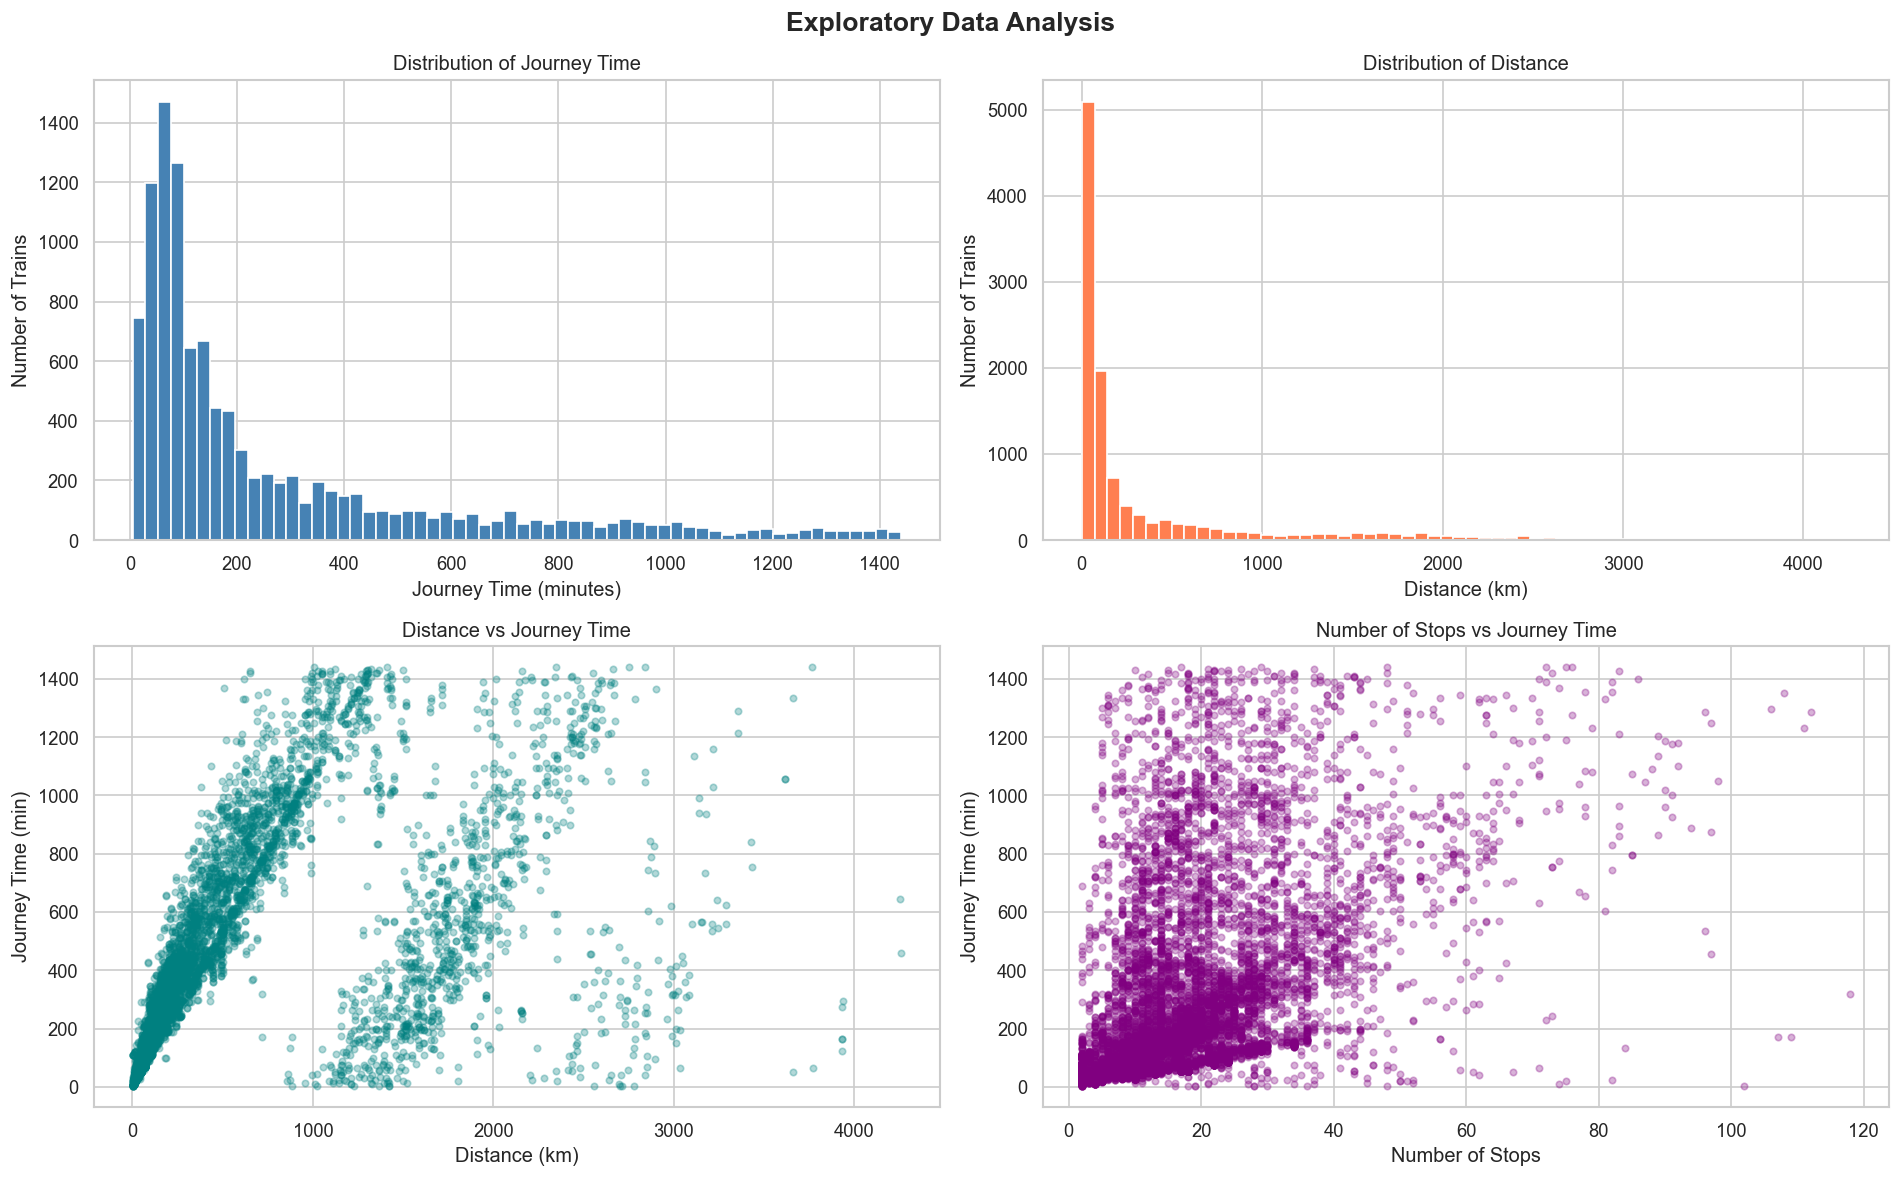

In [70]:
# 4 plots: distributions of journey time and distance, scatter plots showing relationships with the target variable.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

axes[0,0].hist(journey_df['journey_time_min'], bins=60,
               color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of Journey Time')
axes[0,0].set_xlabel('Journey Time (minutes)')
axes[0,0].set_ylabel('Number of Trains')

axes[0,1].hist(journey_df['total_distance_km'], bins=60,
               color='coral', edgecolor='white')
axes[0,1].set_title('Distribution of Distance')
axes[0,1].set_xlabel('Distance (km)')
axes[0,1].set_ylabel('Number of Trains')

axes[1,0].scatter(journey_df['total_distance_km'],
                  journey_df['journey_time_min'],
                  alpha=0.3, color='teal', s=15)
axes[1,0].set_title('Distance vs Journey Time')
axes[1,0].set_xlabel('Distance (km)')
axes[1,0].set_ylabel('Journey Time (min)')

axes[1,1].scatter(journey_df['num_stops'],
                  journey_df['journey_time_min'],
                  alpha=0.3, color='purple', s=15)
axes[1,1].set_title('Number of Stops vs Journey Time')
axes[1,1].set_xlabel('Number of Stops')
axes[1,1].set_ylabel('Journey Time (min)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

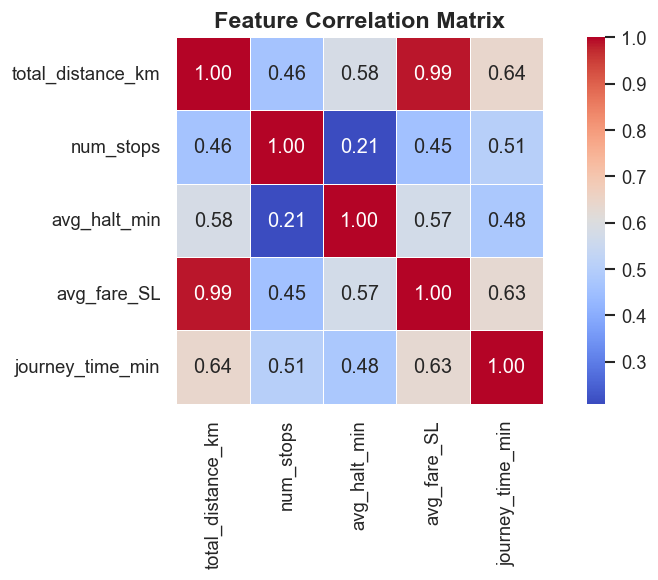

In [71]:
# Shows which features are most correlated with journey time.

plt.figure(figsize=(8, 5))
cols = ['total_distance_km','num_stops','avg_halt_min',
        'avg_fare_SL','journey_time_min']
corr = journey_df[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [72]:
# Define X (features) and y (target), split into train/test sets, and scale with StandardScaler.

FEATURES = ['total_distance_km', 'num_stops',
            'avg_halt_min', 'avg_fare_SL']
TARGET   = 'journey_time_min'

X = journey_df[FEATURES]
y = journey_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'Features used    : {FEATURES}')
print('Data split and scaled!')

Training samples : 8887
Testing samples  : 2222
Features used    : ['total_distance_km', 'num_stops', 'avg_halt_min', 'avg_fare_SL']
Data split and scaled!


In [73]:
# Fit the model and print the coefficient (weight) of each feature.

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model trained!')
print('\n--- Feature Coefficients ---')
coeff_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coeff_df['Meaning'] = coeff_df['Coefficient'].apply(
    lambda c: f'+{c:.2f} min per unit' if c > 0 else f'{c:.2f} min per unit'
)
print(coeff_df.to_string(index=False))
print(f'\nIntercept: {model.intercept_:.2f} minutes')

Model trained!

--- Feature Coefficients ---
          Feature  Coefficient              Meaning
total_distance_km   120.052478 +120.05 min per unit
        num_stops    95.370230  +95.37 min per unit
     avg_halt_min    93.520115  +93.52 min per unit
      avg_fare_SL   -20.970122  -20.97 min per unit

Intercept: 278.07 minutes


In [74]:
# Compute MAE, RMSE, and R² for both train and test sets. R² close to 1.0 = good model.

y_pred_test  = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)

y_pred_test  = np.maximum(y_pred_test, 0)
y_pred_train = np.maximum(y_pred_train, 0)

mae      = mean_absolute_error(y_test, y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2       = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print('=' * 48)
print('         MODEL PERFORMANCE REPORT')
print('=' * 48)
print(f'  Mean Absolute Error  (MAE)  : {mae:.2f} min')
print(f'  Root Mean Sq. Error  (RMSE) : {rmse:.2f} min')
print(f'  R² Score  (Test)            : {r2:.4f}')
print(f'  R² Score  (Train)           : {r2_train:.4f}')
print('=' * 48)
print(f'\nModel explains {r2*100:.1f}% of variance in journey time.')
print(f'Average prediction error: {mae:.1f} minutes.')

         MODEL PERFORMANCE REPORT
  Mean Absolute Error  (MAE)  : 143.08 min
  Root Mean Sq. Error  (RMSE) : 270.58 min
  R² Score  (Test)            : 0.2780
  R² Score  (Train)           : 0.5159

Model explains 27.8% of variance in journey time.
Average prediction error: 143.1 minutes.


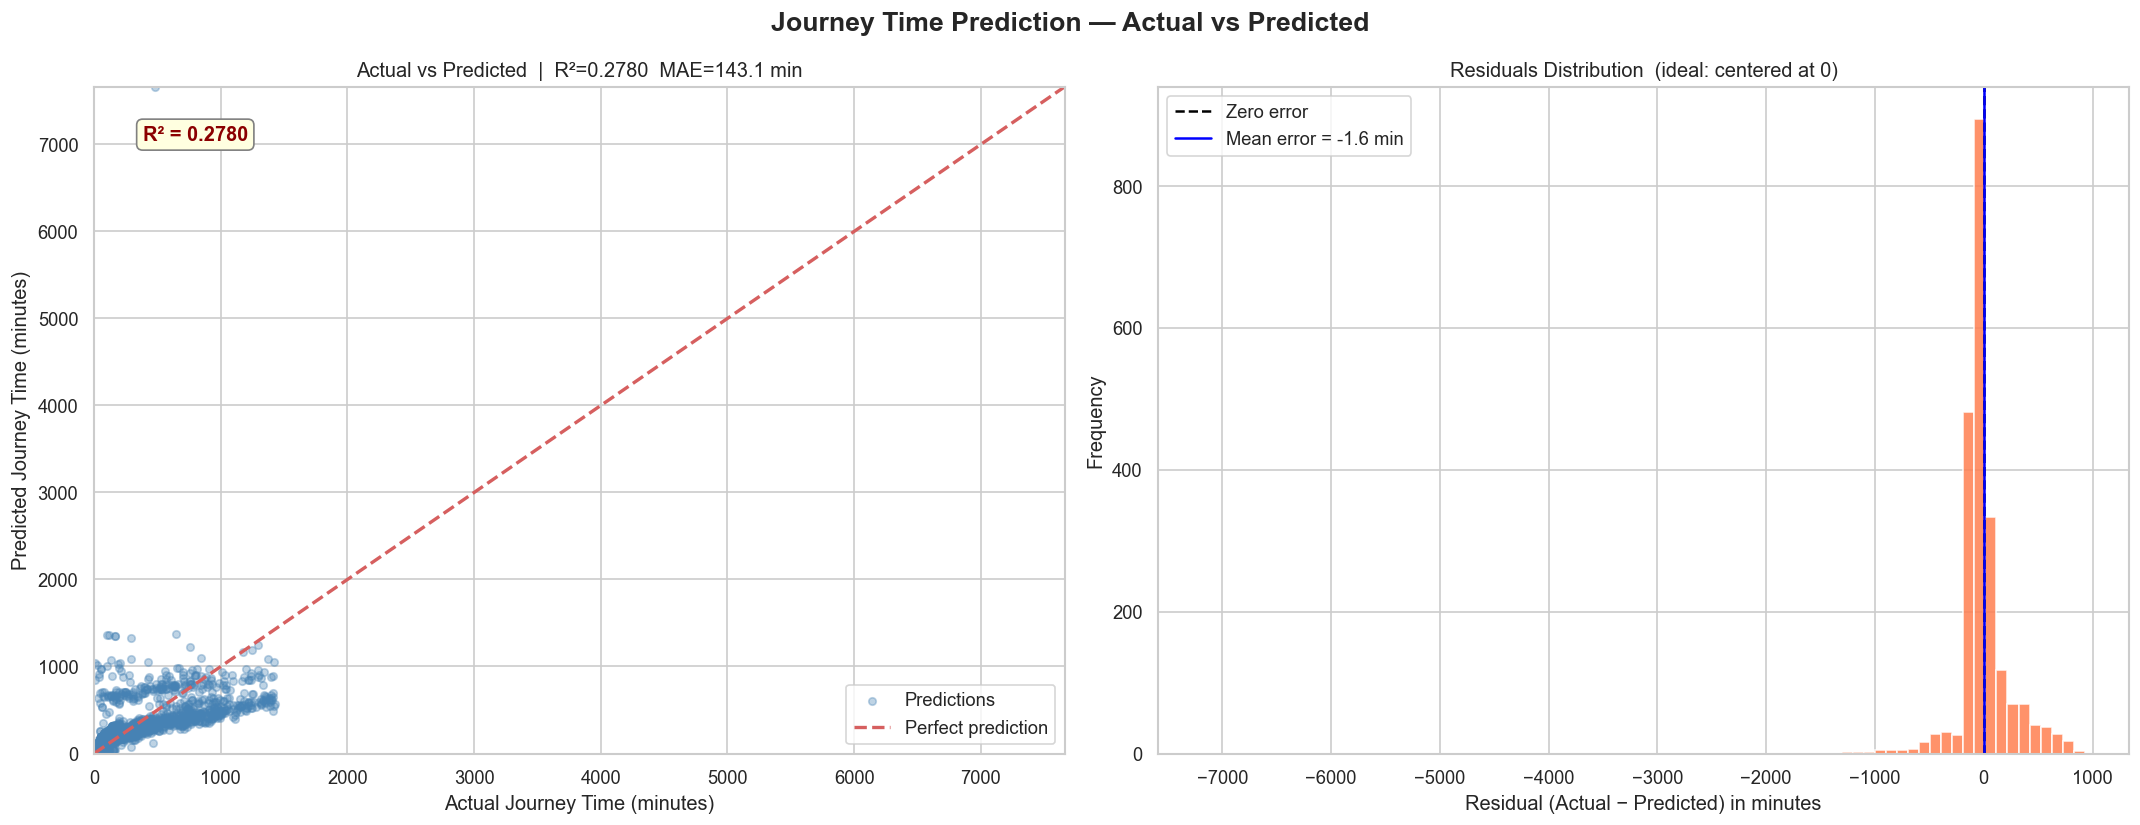

In [75]:
# The main visualization. Left: scatter plot with perfect-prediction diagonal. 
# Right: residuals histogram (should be centered at 0).

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Journey Time Prediction — Actual vs Predicted',
             fontsize=16, fontweight='bold')

# --- Scatter: Actual vs Predicted ---
ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, alpha=0.35,
            color='steelblue', s=20, label='Predictions')

lim_max = max(y_test.max(), y_pred_test.max())
lims = [0, lim_max]
ax1.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Journey Time (minutes)')
ax1.set_ylabel('Predicted Journey Time (minutes)')
ax1.set_title(f'Actual vs Predicted  |  R²={r2:.4f}  MAE={mae:.1f} min')
ax1.legend()
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.text(0.05, 0.92, f'R² = {r2:.4f}',
         transform=ax1.transAxes, fontsize=12,
         color='darkred', fontweight='bold',
         bbox=dict(facecolor='lightyellow', edgecolor='gray',
                   boxstyle='round,pad=0.3'))

# --- Residuals histogram ---
ax2 = axes[1]
residuals = y_test.values - y_pred_test
ax2.hist(residuals, bins=80, color='coral',
         edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linestyle='--',
            linewidth=1.5, label='Zero error')
ax2.axvline(residuals.mean(), color='blue', linestyle='-',
            linewidth=1.5,
            label=f'Mean error = {residuals.mean():.1f} min')
ax2.set_xlabel('Residual (Actual − Predicted) in minutes')
ax2.set_ylabel('Frequency')
ax2.set_title('Residuals Distribution  (ideal: centered at 0)')
ax2.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

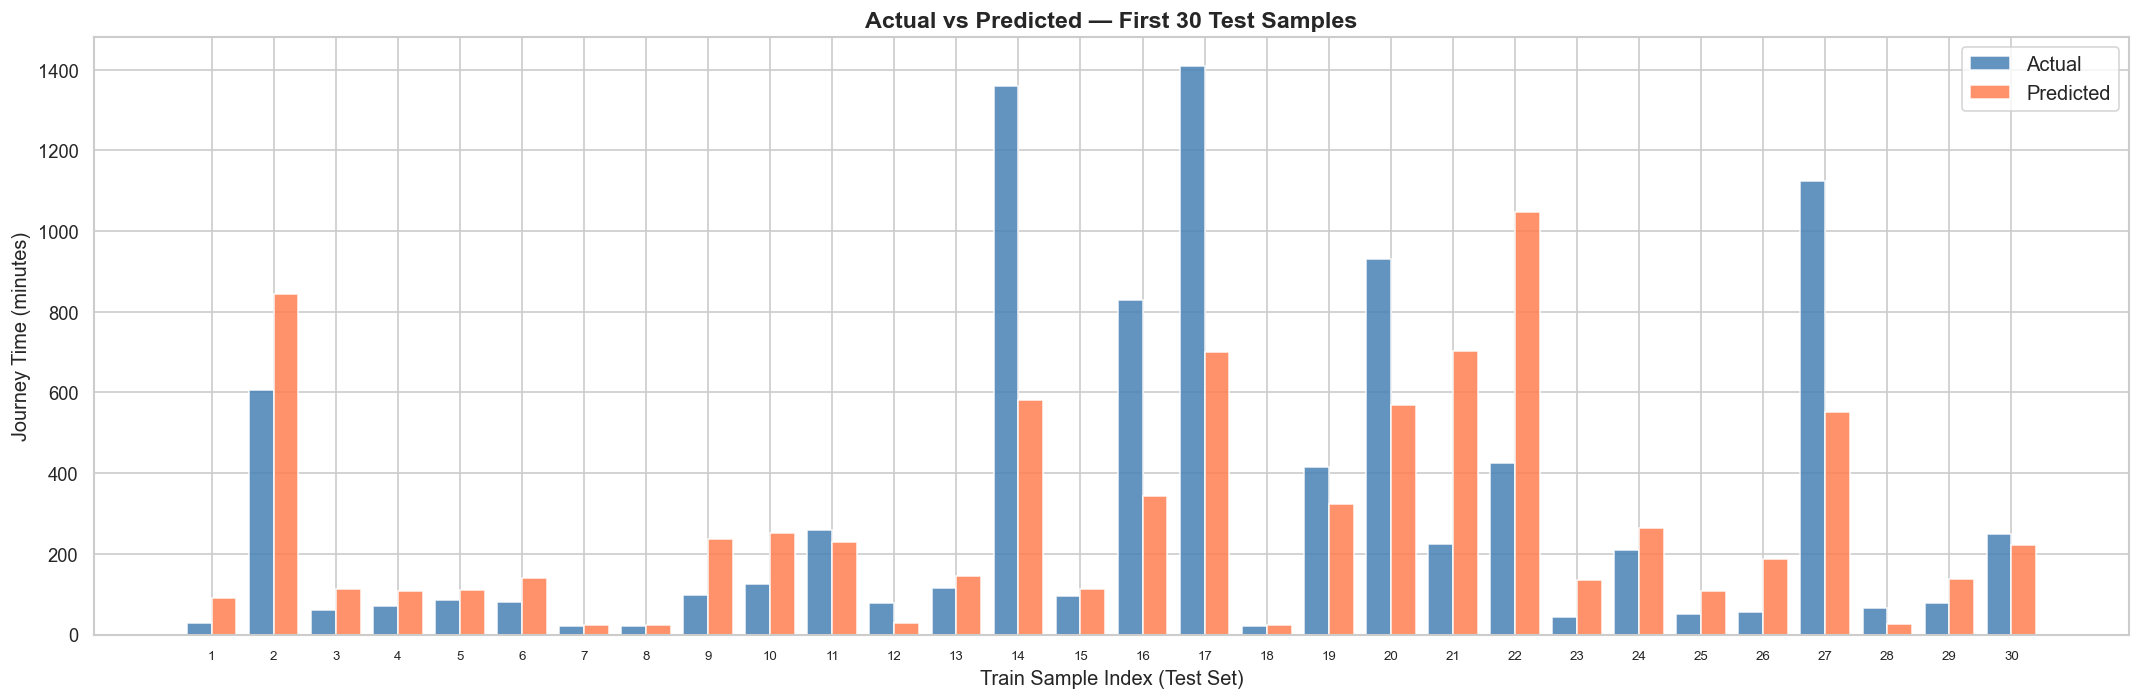

In [76]:
# Side-by-side bars comparing actual vs predicted for the first 30 trains in the test set.

n_show = 30
actual_sample    = y_test.values[:n_show]
predicted_sample = y_pred_test[:n_show]

x_pos = np.arange(n_show)
width = 0.4

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x_pos - width/2, actual_sample,    width,
       label='Actual',    color='steelblue', alpha=0.85)
ax.bar(x_pos + width/2, predicted_sample, width,
       label='Predicted', color='coral',     alpha=0.85)

ax.set_xlabel('Train Sample Index (Test Set)')
ax.set_ylabel('Journey Time (minutes)')
ax.set_title(f'Actual vs Predicted — First {n_show} Test Samples',
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([str(i+1) for i in range(n_show)], fontsize=8)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('bar_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

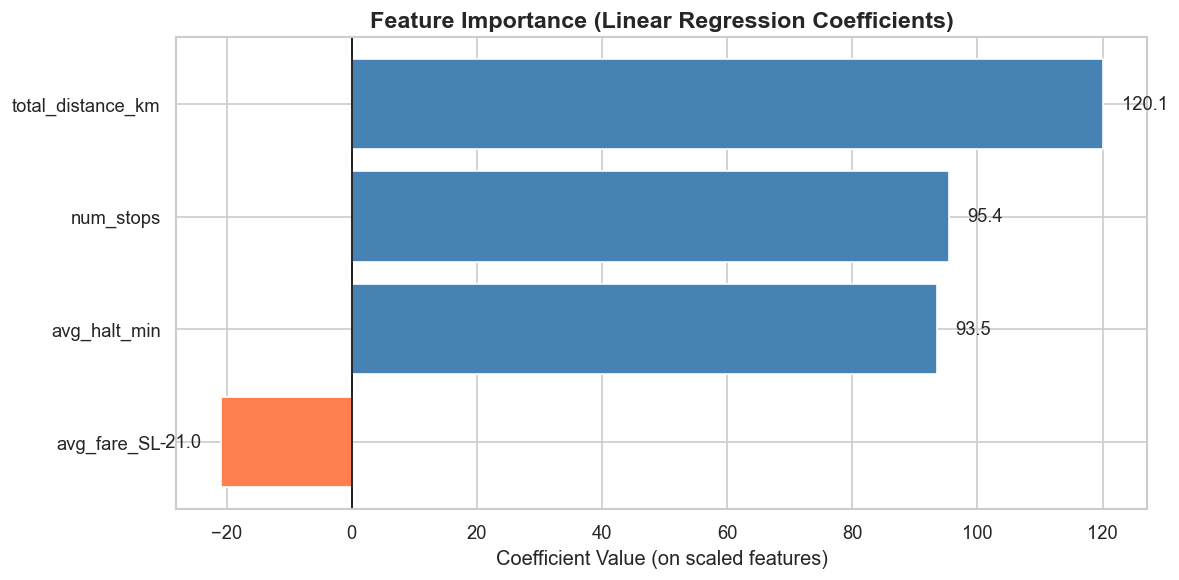

In [77]:
# Horizontal bar chart showing which features have the biggest impact on predictions.

coeff_sorted = coeff_df.sort_values('Coefficient')
colors = ['coral' if c < 0 else 'steelblue'
          for c in coeff_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(coeff_sorted['Feature'],
               coeff_sorted['Coefficient'],
               color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient Value (on scaled features)')
ax.set_title('Feature Importance (Linear Regression Coefficients)',
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, coeff_sorted['Coefficient']):
    offset = 3 if val >= 0 else -3
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', ha=ha, fontsize=11)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()